In [1]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/illegal-dumping-nov12-2025/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm



np.random.seed(999)


from bstpp.main import Hawkes_Model
from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution

from bstpp.cox_hawkes_shared import Cox_Hawkes_Shared, attach_litter_survey_args, attach_dumping_report_args, plot_dumping_report_regression

JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [2]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")


## Loadding shapefiles for plotting

### CBG border and Land care data

In [3]:

# load philly cbg border
pa_2023 = gpd.read_file(f"data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp")
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg=26918)

In [4]:
## load land care data
land_care = gpd.read_file(f"data/Land_Care/phs_landcare.geojson")

land_care['year'] = pd.to_numeric(land_care['year'], errors='coerce')

## Filter for years between 2021 and 2025
land_care_21_25= land_care[(land_care['year'] >= 2021) & (land_care['year'] <= 2025)]

land_care_21_25 = land_care_21_25.to_crs(epsg=26918)

### Land Use

In [5]:
## load land use data
land_use_current = gpd.read_file(f"data/Land_Use/Land_use.geojson")

## recategorize land use types
land_use_current['type'] = pd.Series(dtype='object')

# residential
land_use_current.loc[(land_use_current['c_dig2'] == 11),'type'] = "Res Low Den"
land_use_current.loc[(land_use_current['c_dig2'] == 12),'type'] = "Res Med Den"
land_use_current.loc[(land_use_current['c_dig2'] == 13),'type'] = "Res High Den"
# commercial
land_use_current.loc[
    (land_use_current['c_dig2'] == 21) | (land_use_current['c_dig2'] == 22)|(land_use_current['c_dig2'] == 23),
    'type'
] = "Commercial"
# civic 
land_use_current.loc[
    (land_use_current['c_dig2'] == 41) | (land_use_current['c_dig2'] == 61)|(land_use_current['c_dig2'] == 62)|(land_use_current['c_dig2'] == 71)|(land_use_current['c_dig2'] == 72),
    'type'
] = "Civic"
# other
land_use_current.loc[(land_use_current['c_dig2'] == 31),'type'] = "Industry"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Transportation"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Green ROW"
land_use_current.loc[(land_use_current['c_dig2'] == 81),'type'] = "Water"
land_use_current.loc[(land_use_current['c_dig2'] == 91),'type'] = "Vacant"
land_use_current.loc[(land_use_current['c_dig2'] == 92),'type'] = "Other"

In [6]:
## Customize color map for land use categories
use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

use_color = dict(zip(colors,use_lst))

## reset order in land_use_currect
land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

land_use_current = land_use_current.to_crs(epsg=26918)

In [7]:
# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# fig, ax = plt.subplots(figsize=(9,9))
# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.9,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )
# plt.title('Land Use Types')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/land_use.png', dpi=500, bbox_inches='tight')
# plt.show()

### Vacant Block

In [8]:
## load data
vacant_block = gpd.read_file(f"data/Vacant_Block_Percent_Land.geojson")
vacant_block = vacant_block.to_crs(epsg=26918)

## Loadding illegal dumping data

### Public-accessible 311: 2014 till now

In [9]:
## load 2024 data
litter_25 = gpd.read_file('data/311/2025/public_cases_fc.shp')
## filter data
illegal_dumping_25 = litter_25[litter_25['service_na'] == "Illegal Dumping"]

## load 2024 data
litter_24 = gpd.read_file('data/311/2024/public_cases_fc.shp')
## filter data
illegal_dumping_24 = litter_24[litter_24['service_na'] == "Illegal Dumping"]

## load 2023 data
litter_23 = gpd.read_file('data/311/2023/public_cases_fc.shp')
## filter data
illegal_dumping_23 = litter_23[litter_23['service_na'] == "Illegal Dumping"]

## load 2022 data
litter_22 = gpd.read_file('data/311/2022/public_cases_fc.shp')
## filter data
illegal_dumping_22 = litter_22[litter_22['service_na'] == "Illegal Dumping"]

## load 2021 data
litter_21 = gpd.read_file('data/311/2021/public_cases_fc.shp')
## filter data
illegal_dumping_21 = litter_21[litter_21['service_na'] == "Illegal Dumping"]

In [10]:
## concact 2021, 2022, 2023, and 2024 data
illegal_dumping = pd.concat([
    illegal_dumping_21,
    illegal_dumping_22,
    illegal_dumping_23,
    illegal_dumping_24,
    illegal_dumping_25
])
#illegal_dumping = illegal_dumping_23
total_days = 365 * 5

illegal_dumping = illegal_dumping.to_crs(epsg=26918)

In [11]:
## export to geojson
#illegal_dumping.to_file('output/illegal_dumping_21_24.geojson', driver='GeoJSON')

### 311 Data from the teams

In [ ]:
# ## loadding filtered 311 data
# illegal_dumping = gpd.read_file(f"output/illegal_dumping_full.geojson")

# ## filter out cases after 2024-12-31
# illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-01-01']

# ## set total days
# total_days = 365 * 4

# print(illegal_dumping.shape[0])

109815


In [ ]:
# ## break down material type
# # Split the categories and create a list of all categories
# all_categories = illegal_dumping['material_type'].str.split(';').explode().str.strip()

# # Find the unique values
# unique_categories = all_categories.unique()

# # Print the unique categories
# print(unique_categories)

['Other' 'Mattress and Furniture' 'Mattress/Furniture'
 'Construction Material' 'Construction Materials' 'Appliances'
 "TV's and Monitors" 'TV?s and Monitors' None 'Mattress & Furniture'
 'Tires' 'Building Materials']


### 311 Data - first case within clusters

## Loadding shapefiles

### Loadding park boundaries

In [11]:
## load philly's city map for mapping
philly_border = gpd.read_file(f"data/City_Limits/City_Limits.shp")

philly_border = philly_border.to_crs(epsg=26918)

## load PPR data
ppr =gpd.read_file(f"parks/PPR/PPR_Properties.geojson")
ppr = ppr.to_crs(26918)

## get Cobbs Creek's map
cobbscreek = ppr[ppr["OBJECTID"].isin([432])]

## get Mifflin Square's map
mifflin = ppr[ppr["OBJECTID"].isin([208])]

## Tacony
tacony = ppr[ppr["OBJECTID"].isin([10, 64])]

## Fairmount
fairmount = ppr[ppr["OBJECTID"].isin([7, 9])]

#### Setting boxes around parks

In [12]:
## list of parks
parks = {
    'cobbscreek': cobbscreek,
    'mifflin': mifflin,
    'tacony': tacony,
    'fairmount': fairmount
}

# set buffer value
buffer = 300 # meters

# collect results
all_parks_gdf = gpd.GeoDataFrame() # for plotting
all_boxes_gdf = gpd.GeoDataFrame() # for filtering

# loop: get boxes around 
for name, gdf in parks.items():
    # skip empty GeoDataFrames
    if gdf.empty:
        continue
    
    # store parks geometries
    all_parks_gdf = pd.concat([all_parks_gdf, gdf], ignore_index=True)

    # compute total bounds
    minx, miny, maxx, maxy = gdf.total_bounds
    minx -= buffer
    maxx += buffer
    miny -= buffer
    maxy += buffer

    # compute the side length of the square
    side = max(maxx - minx, maxy - miny)
    center_x = (minx + maxx) / 2
    center_y = (miny + maxy) / 2

    # create square box
    square_minx = center_x - side / 2
    square_maxx = center_x + side / 2
    square_miny = center_y - side / 2
    square_maxy = center_y + side / 2
    square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

    # create GeoDataFrame for box
    square_gdf = gpd.GeoDataFrame(
        {'PARKNAME': [f"{name}_box"]},
        geometry=[square_geom],
        crs=gdf.crs
    )

    # add box to collection
    all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf], ignore_index=True)

## Loadding cbg-level cov dataset

In [13]:
## load covariates
cov_gdf = gpd.read_file(f"output/cov_cbg.geojson")
cov_gdf = cov_gdf.to_crs(epsg=26918)

In [14]:
cov_gdf.columns

Index(['state', 'county', 'tract', 'block group', 'GEOID', 'pop_density',
       'med_inc_avg', 'lep_density', 'edu_hs_avg', 'vac_area', 'ndvi_mean_4yr',
       'RLD', 'RMD', 'RHD', 'CC', 'CBP', 'CMR', 'I', 'Civic', 'T', 'GW',
       'Cult', 'AR', 'Park', 'Cemetery', 'Water', 'VL', 'Other', 'use_res',
       'use_com', 'use_civ', 'landcare_area', 'area_B', 'alloc_avg_d_cnt',
       'alloc_avg_s_cnt', 'unique_device_ratio_aw', 'reporting_rate',
       'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d',
       'pagerank_avg_d', 'geometry'],
      dtype='object')

### Filtering points in each park

In [15]:


# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: filter to only keep points that are also in cov_cbg
illegal_dumping_in_park = illegal_dumping_in_park.sjoin(
    cov_gdf, 
    predicate='within', 
    how='inner'  # Only keep points that match both conditions
)

# set park name
park_name = "tacony_box"

park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == park_name]
park_points.shape

(7730, 62)

In [32]:
# Plotting
#fig, ax = plt.subplots(figsize=(5, 5))

# Plot jittered points in blue
#park_points.plot(ax=ax, color='blue', markersize=10, label='Jittered',alpha=0.5)

# Create a GeoSeries for original points
#gdf_original = gpd.GeoSeries(park_points['geometry'], crs=park_points.crs)
#gdf_original.plot(ax=ax, color='pink', markersize=10, label='Original',alpha=0.5)

# Add legend and title
#plt.legend()
#plt.title("Original vs. Jittered Park Points")
#plt.show()

### Jittering time

In [18]:
random_offsets = np.random.uniform(0, 24 * 60 * 60, size=len(park_points))
park_points['jittered_time'] = park_points['requested_'] + pd.to_timedelta(random_offsets, unit='s')

/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Generating locs_s - using original timestamp - <span style = "color:#990000" >UPDATED</span>

In [21]:
# get coordinates from the geometry
coords = pd.DataFrame({
    'x': park_points.geometry.centroid.x,
    'y': park_points.geometry.centroid.y
})

# calculate time difference in days from the minimum date
offset_seasonal = 30 * 0
min_year        = pd.to_datetime(park_points['jittered_time'].min())
min_time        = pd.Timestamp(f"{min_year.year}-01-01")
time            = (park_points['jittered_time'] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal        = (time + offset_seasonal) % 365
park_points['time_diff']     = time
park_points['seasonal_diff'] = seasonal

# Create locs_s DataFrame
locs_s = pd.DataFrame({
    'X': coords['x'].astype(float),
    'Y': coords['y'].astype(float),
    'T': time.astype(float),
    'A': seasonal.astype(float)
})


/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [22]:
park_points.crs

<Projected CRS: EPSG:26918>
Name: NAD83 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 78°W and 72°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Connecticut; Delaware; Maryland; Massachusetts; New Hampshire; New Jersey; New York; North Carolina; Pennsylvania; Virginia; Vermont.
- bounds: (-78.0, 28.28, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [23]:
cov_gdf.columns

Index(['state', 'county', 'tract', 'block group', 'GEOID', 'pop_density',
       'med_inc_avg', 'lep_density', 'edu_hs_avg', 'vac_area', 'ndvi_mean_4yr',
       'RLD', 'RMD', 'RHD', 'CC', 'CBP', 'CMR', 'I', 'Civic', 'T', 'GW',
       'Cult', 'AR', 'Park', 'Cemetery', 'Water', 'VL', 'Other', 'use_res',
       'use_com', 'use_civ', 'landcare_area', 'area_B', 'alloc_avg_d_cnt',
       'alloc_avg_s_cnt', 'unique_device_ratio_aw', 'reporting_rate',
       'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d',
       'pagerank_avg_d', 'geometry'],
      dtype='object')

## Model fitting

In [ ]:
## Cox-Hawkes model

# a_0 = baseline log-intensity
# alpha = magnitute of excitation
# bate = temporal decay rate
# sigmax_2 = spatial decay scale
column_names = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
                ,'RLD', 'RMD','RHD','use_com', 'use_civ','I', 'T', 'GW',
                'vac_area','landcare_area',
                'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw','reporting_rate',
                'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

model = bstpp.main.Hawkes_Model(
    locs_s,     # spatiotemporal points
    #univ_square_gdf,
    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
    total_days, # Time frame
    True,       # use Cox as background
    spatial_cov = cov_gdf,#spatial covariate matrix
    cov_names = column_names,#columns to use from covariates
    standardize_cov = True,
    a_0      = dist.Normal(0,2),
    alpha    = dist.Beta(2,2),
    #beta     = dist.HalfNormal(1.0),
    beta     = dist.Exponential(1.0),
    gamma    = dist.Exponential(1.0),
    sigmax_2 = dist.HalfNormal(0.25),
    offset_seasonal = offset_seasonal,
    temporal_trig = bstpp.trigger.Temporal_Power_Law
)


[DEBUG] set_window called with:
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[DEBUG] aligned_difference_pairs called with:
  t type: <class 'numpy.ndarray'> dtype: float64 shape: (7730,)
  x type: <class 'numpy.ndarray'> dtype: float64 shape: (7730,)
  y type: <class 'numpy.ndarray'> dtype: float64 shape: (7730,)
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[set_window] Temporal window set to: 100.0
[set_window] Number of events: 7730
[set_window] Number of pairs: 1557561
[set_window] Max t_diff in pairs: 49.897041171132095
[set_window] Min t_diff in pairs: 8.490312362496866e-06
[set_window] All t_diff <= window: True
[set_window] All t_diff > 0: True
[set_window] Spatial window set to: 0.1
[set_window] Max spatial distance: 0.09999986737966537
[set_window] Min spatial distance: 0.0
[set_window] All spatial distances <= window: True


  0%|          | 0/10000 [00:00<?, ?it/s]2026-08-19 11:59:14.555903: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %slice.1857 = s32[1557561,1]{1,0} slice(s32[1557561,2]{1,0} %constant.218), slice={[0:1557561], [0:1]}, metadata={op_name="jit(body_fn)/jit(main)/slice[start_indices=(0, 0) limit_indices=(1557561, 1) strides=None]" source_file="/Users/yuxin/BSTPP/bstpp/inference_functions.py" source_line=168}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-08-19 11:59:17.643269: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 4.0925s
Constant folding an

Number of posterior samples: 1000
Number of pairs: 1557561
coords shape: (1557561, 2)

SVI elapsed time: 275.2866950035095


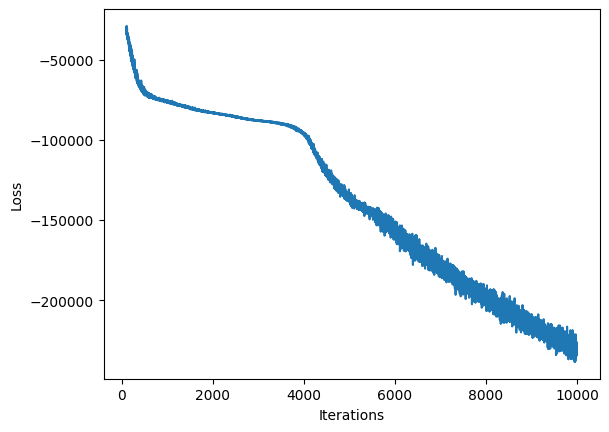

In [25]:
model.set_window(window = 100, spatial_window= 0.1)
## 100

# less interations and bigger learning rate
model.run_svi(lr=0.01,num_steps=10000)
#model.run_svi(lr=0.03,num_steps=10000)

## Results

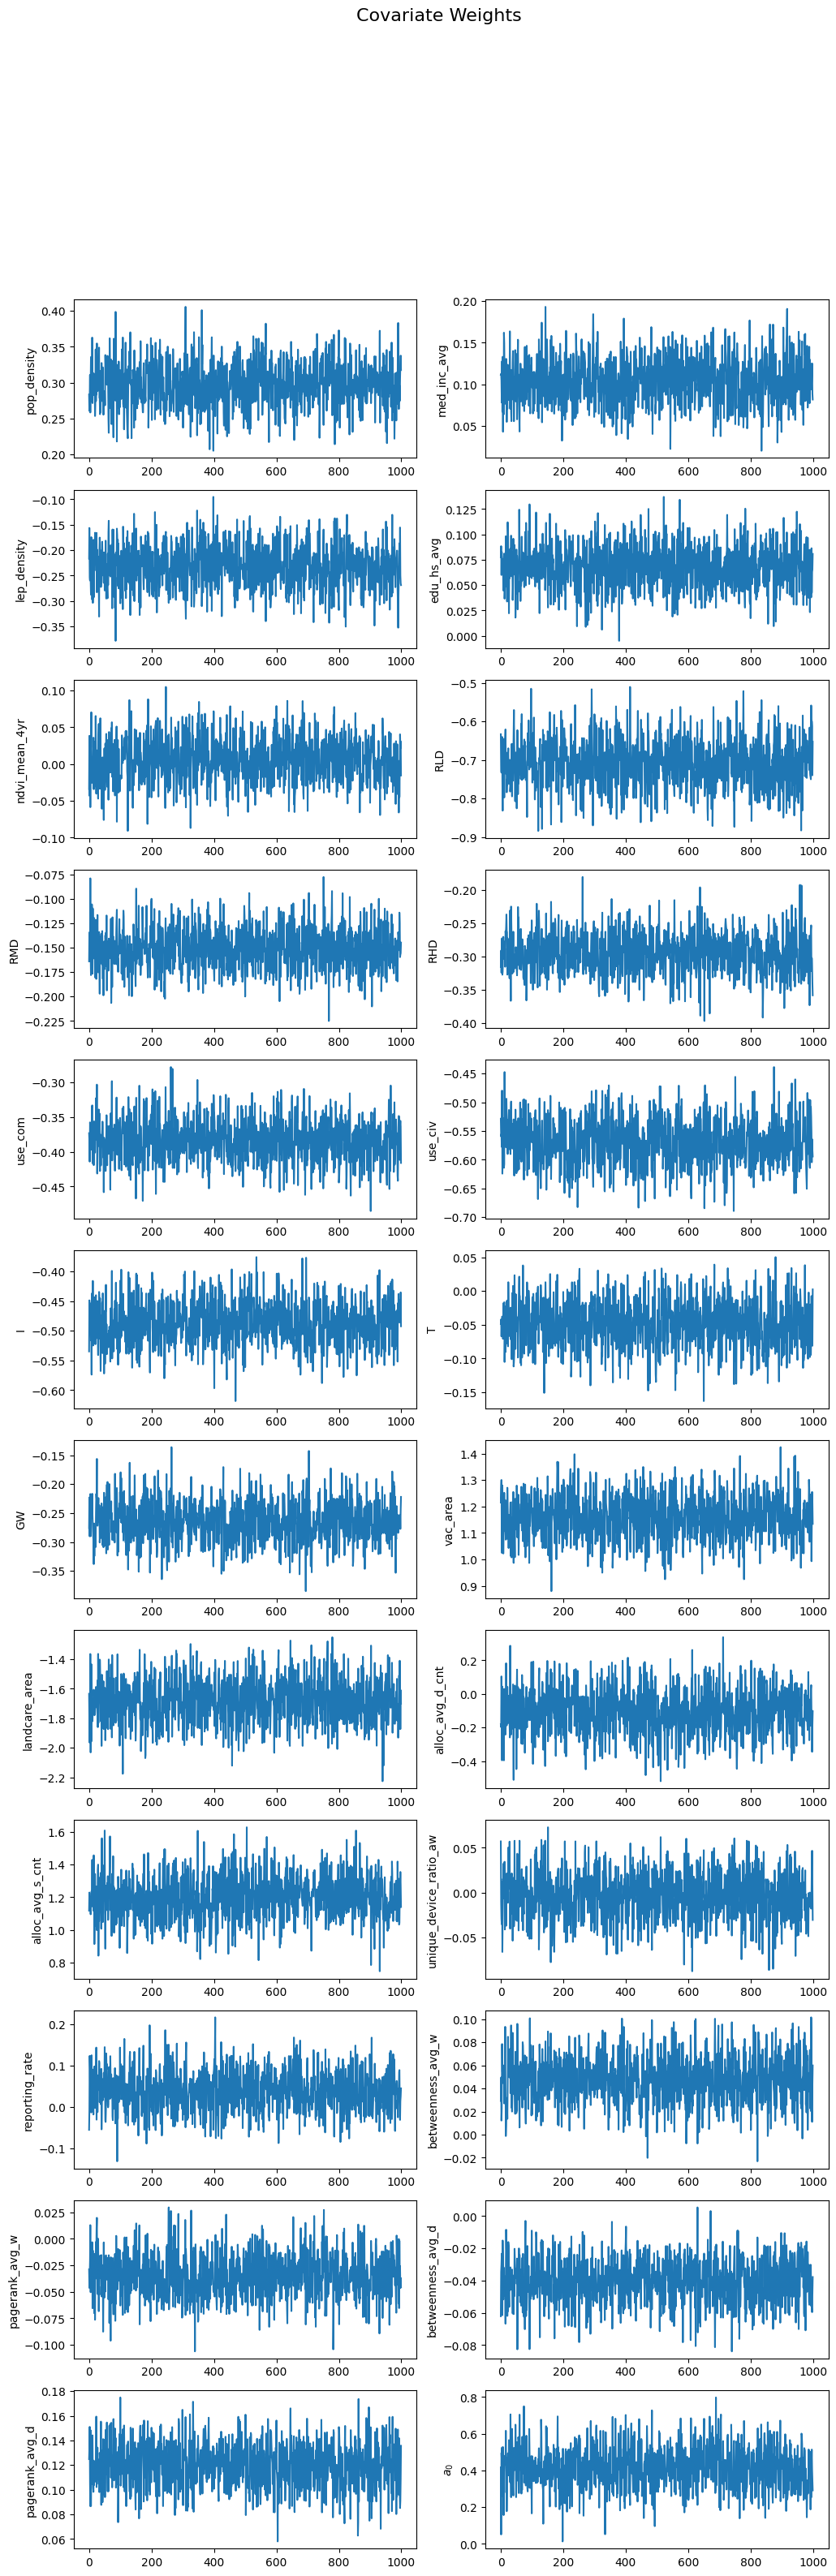

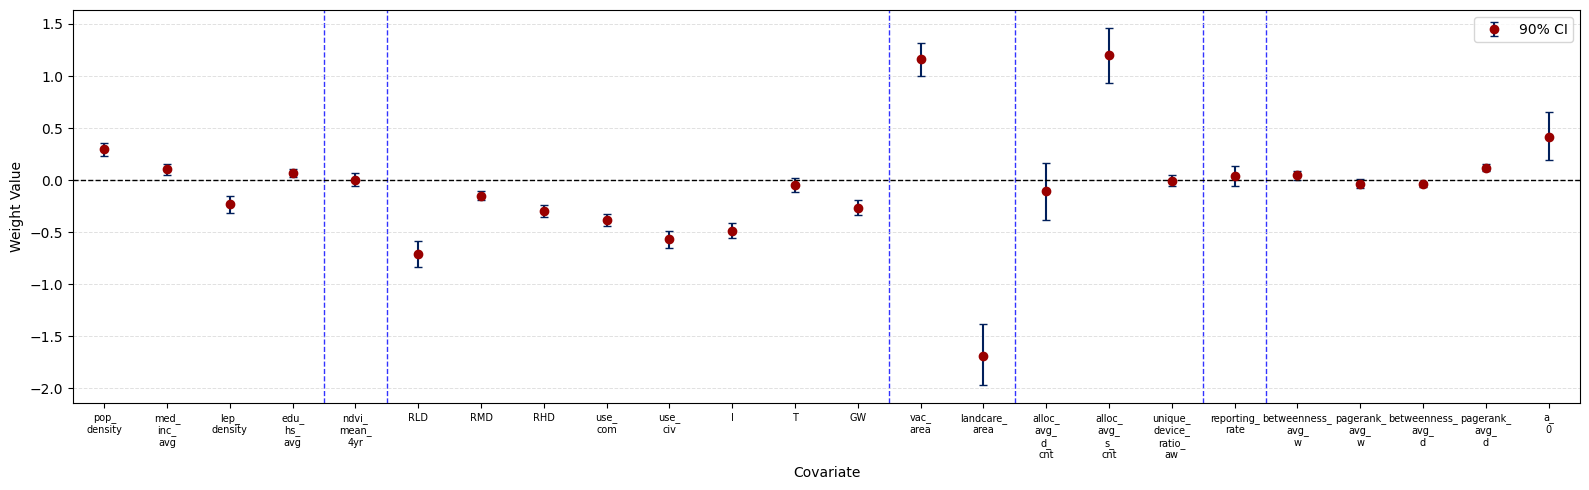

,Post Mean,Post Std,P(w>0),[0.025,0.975]
pop_density,0.297002,0.031402,1.000,0.232877,0.359817
med_inc_avg,0.104096,0.028108,1.000,0.052046,0.159407
lep_density,-0.232224,0.042581,0.000,-0.314415,-0.152761
edu_hs_avg,0.068530,0.021327,0.999,0.027626,0.108950
ndvi_mean_4yr,0.005520,0.029973,0.578,-0.053561,0.064530
RLD,-0.707662,0.062283,0.000,-0.832398,-0.585479
RMD,-0.150578,0.021222,0.000,-0.192170,-0.108262
RHD,-0.294926,0.030696,0.000,-0.354199,-0.234606
use_com,-0.383767,0.030269,0.000,-0.444102,-0.321653
use_civ,-0.569317,0.040719,0.000,-0.648743,-0.491381


In [26]:
model.cov_weight_post_summary(trace=True)

- Higher values indicate better model fit to the data

In [27]:
model.log_expected_likelihood(locs_s)

Final test_args keys: ['T', 'S', 't_min', 'x_min', 'x_max', 'y_min', 'y_max', 'model', 'offset_seasonal', 'A_area', 'A_', 'n_t', 'x_t', 'n_s', 'x_a', 'n_xy', 'spatial_grid_cells', 't_events', 'indices_t', 'a_events', 'indices_a', 'indices_xy', 'xy_events', 'gp_kernel', 'hidden_dim_temporal', 'z_dim_temporal', 'hidden_dim1_seasonal', 'hidden_dim2_seasonal', 'z_dim_seasonal', 'hidden_dim1_spatial', 'hidden_dim2_spatial', 'z_dim_spatial', 'decoder_params_temporal', 'decoder_params_seasonal', 'decoder_params_spatial', 'cov_ind', 'num_cov', 'spatial_cov', 'int_df', 'sp_var_mu', 'priors', 't_trig', 'sp_trig', 'window', 'spatial_window', 'coords', 't_vals', 'x_vals', 'y_vals', 'hawkes_design']


121260.3671875

In [28]:
model.expected_AIC()

-230664.09375

0.4747231602668762

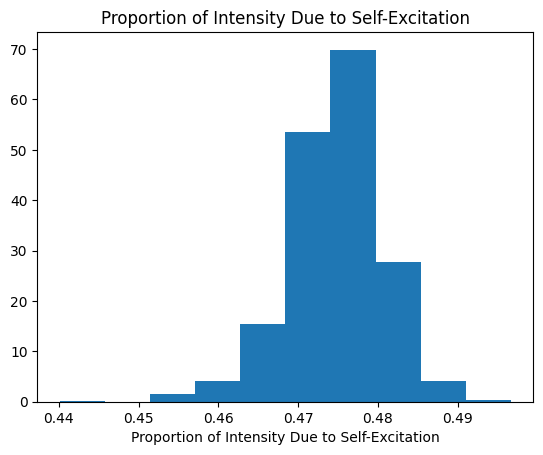

In [29]:
model.plot_prop_excitation()


In [30]:
par_names = model.args['t_trig'].get_par_names()
print(par_names)

['beta', 'gamma']


,Post Mean,Post Std,P(w>0),[0.025,0.975]
alpha,9.328216e-01,2.957410e-02,1.0,8.596151e-01,9.735549e-01
beta,1.546068e-01,7.209381e-03,1.0,1.415742e-01,1.695165e-01
gamma,1.772920e-01,1.059138e-02,1.0,1.570764e-01,1.980272e-01
sigmax_2,4.728965e-16,2.848341e-16,1.0,1.436423e-16,1.268769e-15


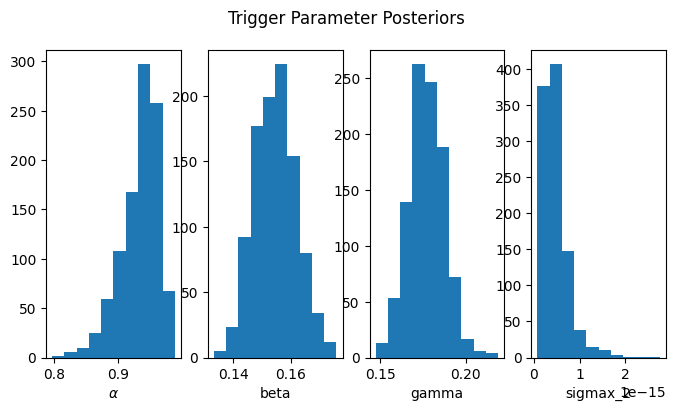

In [31]:
model.plot_trigger_posterior(trace=False)

In [50]:
# ## Spatial trigger ------------------------------------------------------
# # Step 1: Draw the original plot
# model.plot_spatial(include_cov=False)

# # Step 2: Grab the existing figure and axes
# fig = plt.gcf()
# axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# # Match limits from left subplot
# xlim = axs[0].get_xlim()
# ylim = axs[0].get_ylim()

# #philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)

# # Add overlays
# #all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# # Set the same limits on the right subplot
# axs[1].set_xlim(xlim)
# axs[1].set_ylim(ylim)

# # Step 3: Add a new axis to the right
# osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# # Step 4: Draw the OpenStreetMap on the new axis
# osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
# philly_2023_3857 = philly_2023.to_crs(epsg=3857)
# all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
# land_use_current = land_use_current.to_crs(epsg=3857)
# land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
# vacant_block = vacant_block.to_crs(epsg = 3857)

# # plot cbg and park boundary
# philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
# all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
# osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
# #land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
# #vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=osm_ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.8,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )

# # Zoom to Cobbs Creek Park
# xlim = osm_box.total_bounds[[0, 2]]
# ylim = osm_box.total_bounds[[1, 3]]
# osm_ax.set_xlim(xlim)
# osm_ax.set_ylim(ylim)

# ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
# #ctx.add_basemap(osm_ax)


# # Add the scale bar in kilometers
# scalebar = ScaleBar(
#     dx=1,  # 1 pixel = 1 meter (Web Mercator)
#     units='m',  # use kilometers
#     dimension='si-length',
#     length_fraction=0.25,
#     location='lower right',
#     scale_loc='bottom',
#     box_color='white',
#     box_alpha=0.8,
#     border_pad=0.6,
#     color='black',
#     font_properties={'size': 10}
# )
# osm_ax.add_artist(scalebar)

# # Optional: Clean up
# osm_ax.set_title("OpenStreetMap View")
# osm_ax.set_axis_off()

# plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')


In [51]:
# ## Uncertainty map ------------------------------------------------------
# # Get uncertainty measures
# f_xy_samples = model.samples["f_xy"]
# f_xy_mean = np.mean(f_xy_samples, axis=0)
# f_xy_std = np.std(f_xy_samples, axis=0) # Standard deviation across samples

# # Get boundary from model.A geometry
# bounds = model.A[['geometry']].total_bounds  # [minx, miny, maxx, maxy]
# minx, miny, maxx, maxy = bounds

# # Since spatial_grid contains indices, we need to create coordinates
# # For a 625-cell grid, this is likely a 25x25 grid (25² = 625)
# grid_size = int(np.sqrt(625))  # Should be 25
# print(f"Grid size: {grid_size}x{grid_size}")

# # Create coordinate arrays based on actual geometry bounds
# x_indices = np.linspace(minx, maxx, grid_size)
# y_indices = np.linspace(miny, maxy, grid_size)
# X, Y = np.meshgrid(x_indices, y_indices)

# # Reshape your data to match the grid
# f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
# f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# # Create the plots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# # Mean surface
# im1 = ax1.imshow(f_xy_mean_grid, origin='lower', cmap='viridis', extent=[minx, maxx, miny, maxy])
# model.points.plot(ax=ax1,color='red',marker='x',alpha=0.1)
# all_parks_gdf.plot(ax=ax1, edgecolor='white', facecolor='none', linewidth=2)

# ax1.set_title('Mean Posterior $f_s$ With Events')
# ax1.set_xlim(minx, maxx)  # Set x limits to bounds
# ax1.set_ylim(miny, maxy)  # Set y limits to bounds
# plt.colorbar(im1, ax=ax1, shrink=0.7)

# # Uncertainty surface
# im2 = ax2.imshow(f_xy_std_grid, origin='lower', cmap='RdYlGn_r', extent=[minx, maxx, miny, maxy], vmin=0, vmax=0.33)
# all_parks_gdf.plot(ax=ax2, edgecolor='gray', facecolor='none', linewidth=2)

# ax2.set_title('$f_s$ Uncertainty (Std Dev)')
# ax2.set_xlim(minx, maxx)  # Set x limits to bounds
# ax2.set_ylim(miny, maxy)  # Set y limits to bounds
# plt.colorbar(im2, ax=ax2, shrink=0.7)

# plt.tight_layout()
# # plt.savefig('output/uncertainty_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show()

# # Print some summary statistics
# print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
# print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")

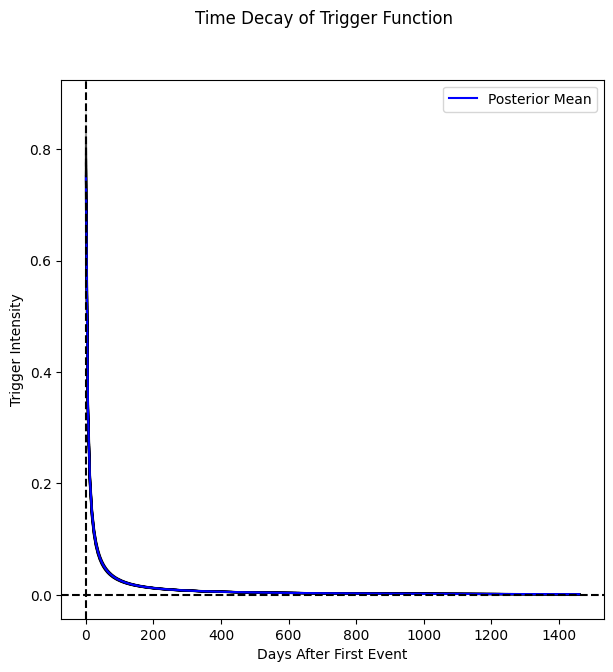

In [52]:
model.plot_trigger_time_decay()

In [53]:
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)


# fig,ax = plt.subplots(figsize=(9,9))

# # Use the hist() function to plot the frequency distribution of delta_t
# ax.hist(df['delta_t_days'], bins=50, edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests')
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# #plt.tight_layout()
# plt.savefig('output/decay_mifflin_full.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [54]:
# ## Delta t distribution ------------------------------------------------------
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)

# # Create manual bins
# min_val = df['delta_t_days'].min()
# max_val = df['delta_t_days'].max()
# bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Print binning information
# num_bins = len(bins) - 1
# bin_width = (max_val - min_val) / num_bins
# actual_time_range = max_val - min_val

# print(f"Number of bins: {num_bins}")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# # Calculate histogram manually
# counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # Create the plot
# fig, ax = plt.subplots(figsize=(9,9))

# # Use bar plot instead of hist
# ax.bar(bin_centers, counts, width=np.diff(bins), edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests',pad=30)
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# #plt.savefig('output/delta_t_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [55]:
# Get parameter names
par_names = model.args['t_trig'].get_par_names()  # ['beta', 'gamma']
params_mean = {}

# Calculate mean of posterior samples for each parameter
for name in par_names:
    params_mean[name] = model.samples[name].mean().item()

prior_value = locs_s
tpl = Temporal_Power_Law(prior_value)

# # # Step 2: Use your extracted parameters (replace params_mean with your actual variable)
# # params_from_model = params_mean  # <-- Replace this with your actual parameter variable
# params_from_model = {
#     'beta': float(params_mean['beta']),   # Convert array to scalar
#     'gamma': float(params_mean['gamma'])  # Convert array to scalar
# }

In [56]:
## Delta t distribution ------------------------------------------------------
df = park_points.copy()

# Ensure the 'start_time' column is in datetime format
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort the DataFrame by 'address' and 'start_time'
df.sort_values(by=['address', 'start_time'], inplace=True)

# Group by address and get the next start time
grouped = df.groupby('address')
df['next_start_time'] = grouped['start_time'].shift(-1)

# Calculate the time difference in days
df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# Drop rows where the next start time is missing
df.dropna(subset=['delta_t_days'], inplace=True)

# Create manual bins
min_val = df['delta_t_days'].min()
max_val = df['delta_t_days'].max()
bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
bin_centers_real = (bins[:-1] + bins[1:]) / 2

# Print binning information
num_bins = len(bins) - 1
bin_width = (max_val - min_val) / num_bins
actual_time_range = max_val - min_val

print(f"Number of bins: {num_bins}")
print(f"Bin width: {bin_width:.4f} days")
print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# Calculate histogram manually
counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # simulated delta t------------------------------------------------------------
# # set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

Number of bins: 1199
Bin width: 1.1918 days
Actual time range: 1429.0194 days (from 0.0000 to 1429.0194)


In [57]:
# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.set_xlim(-10, 200)
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# # plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:841: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_8535/905458466.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


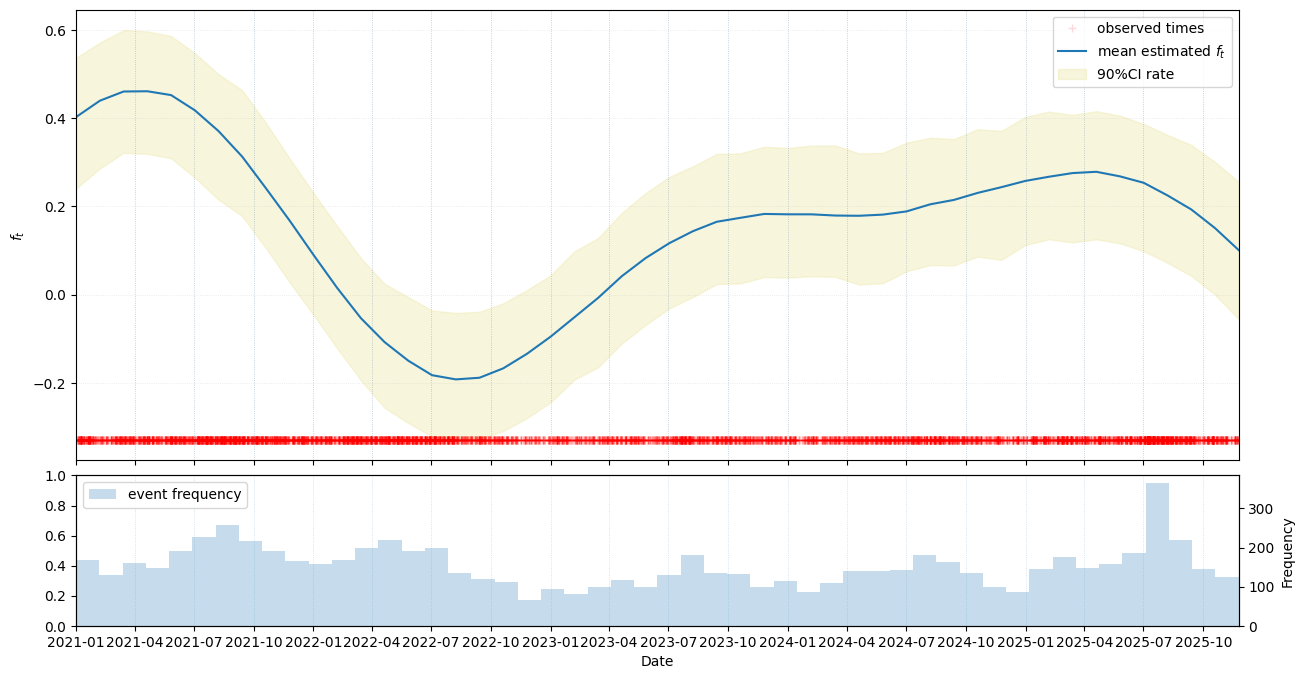

In [35]:
from datetime import datetime

start_date = datetime(2021, 1, 1)  # <-- change this to your real start date

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: don't try to do date formatting inside the method
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: we'll format dates ourselves below
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# ----------------------------
# 3) Add calendar month ticks to the SHARED x-axis (bottom axis renders labels)
#    Assumes x-axis is "t in days" starting from start_date
# ----------------------------
x0, x1 = ax_bottom.get_xlim()
x_max = int(np.ceil(x1))

end_date = start_date + pd.Timedelta(days=x_max)

month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")
label_every_n_months = 3
month_starts_labeled = month_starts[::label_every_n_months]

xticks = [(d.to_pydatetime() - start_date).days for d in month_starts_labeled]
xlabels = [d.strftime("%Y-%m") for d in month_starts_labeled]

ax_bottom.set_xticks(xticks)
ax_bottom.set_xticklabels(xlabels)
ax_bottom.set_xlabel("Date")

# Optional: add vertical month gridlines on BOTH panels for alignment
for ax in (ax_top, ax_bottom):
    for d in month_starts_labeled:
        x = (d.to_pydatetime() - start_date).days
        ax.axvline(x, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_temp_full.png', dpi=500, bbox_inches='tight')
plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_8535/1590998301.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


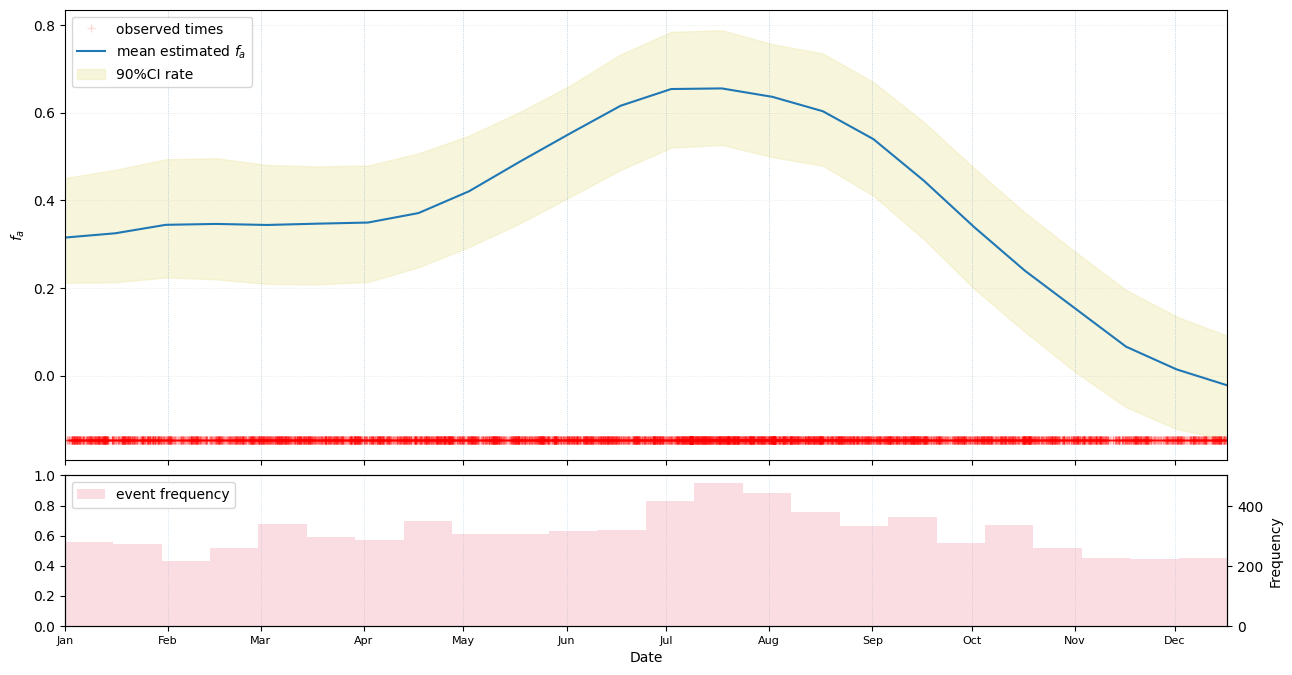

In [36]:


# Set up subplots (similar to temporal example)
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- change this to your reference year if needed
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- same reference year
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# Optional: add vertical month gridlines on BOTH panels for alignment
ref_year = 2021
offset = model.args['offset_seasonal']
month_days = np.cumsum([0] + [calendar.monthrange(ref_year, m)[1] for m in range(1, 12)])
month_days_offset = (month_days + offset) % model.S
sorted_idx = np.argsort(month_days_offset)
month_starts_labeled = month_days_offset[sorted_idx]

b_scale = model.args["n_s"] / model.S if True else 1.0  # adjust based on your rescale setting
x_a = np.arange(0, model.args["S"], model.args["S"]/model.args["n_s"]) / b_scale

for ax in (ax_top, ax_bottom):
    for x_pos in month_starts_labeled:
        ax.axvline(x_pos, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_seasonal_trend.png', dpi=500, bbox_inches='tight')
plt.show()

In [59]:
def simulate_triggers_histogram(beta, gamma, df, locs_s, tpl, scale, 
                                max_time=365*4, num_bins=1200, n_iterations=500):
    """
    Simulate trigger times and generate histogram for given beta and gamma parameters.
    """
    # First calculate the bin width from your data
    data_min = df['delta_t_days'].min()
    data_max = df['delta_t_days'].max()
    data_range = data_max - data_min
    bin_width = data_range / num_bins
    
    # Create bin edges
    num_bins_calc = int(max_time / bin_width)
    bin_edges = np.linspace(0, max_time, num_bins_calc + 1)
    
    # Set up parameters
    params_from_model = {
        'beta': float(beta),
        'gamma': float(gamma)
    }
    
    histogram_matrix = []
    
    for i in range(n_iterations):
        samples = []
        for j in range(locs_s.shape[0]):
            s = tpl.simulate_trigger(params_from_model)
            s_days = s * scale
            samples.append(s_days)
        
        hist_counts, _ = np.histogram(samples, bins=bin_edges)
        histogram_matrix.append(hist_counts)
    
    histogram_matrix = np.array(histogram_matrix)
    column_averages = np.mean(histogram_matrix, axis=0)
    
    return bin_edges, column_averages


def run_posterior_simulations(model, df, locs_s, tpl, scale, 
                              n_posterior_samples=100, **kwargs):
    """
    Run simulations using posterior samples of beta and gamma.
    """
    # Extract parameter names
    par_names = model.args['t_trig'].get_par_names()
    
    # Get total number of posterior samples
    n_samples = len(model.samples[par_names[0]])
    
    # Randomly sample indices
    indices = np.random.choice(n_samples, size=n_posterior_samples, replace=False) # 
    
    all_histograms = []
    
    print(f"\n{'='*70}")
    print(f"Starting posterior simulations with {n_posterior_samples} parameter samples")
    print(f"{'='*70}\n")
    
    # Use tqdm.notebook for Jupyter - it has a nice widget-based progress bar
    pbar = tqdm(total=n_posterior_samples, desc="Overall Progress")
    
    for idx, i in enumerate(indices):
        # Extract beta and gamma for this iteration
        beta = float(model.samples['beta'][i])
        gamma = float(model.samples['gamma'][i])
        
        # Print posterior sample info
        print(f"Posterior sample {idx + 1}/{n_posterior_samples}: beta={beta:.4f}, gamma={gamma:.4f}")
        
        # Run simulation with these parameters
        bin_edges, column_avg = simulate_triggers_histogram(
            beta, gamma, df, locs_s, tpl, scale,
            **kwargs
        )
        
        all_histograms.append(column_avg)
        
        # Update progress bar
        pbar.update(1)
    
    pbar.close()
    
    print(f"\n{'='*70}")
    print("✓ All posterior simulations completed!")
    print(f"{'='*70}\n")
    
    # Convert to array and calculate statistics
    all_histograms = np.array(all_histograms)
    
    print("Calculating statistics across all posterior samples...")
    mean_counts = np.mean(all_histograms, axis=0)
    lower_bound = np.percentile(all_histograms, 2.5, axis=0)
    upper_bound = np.percentile(all_histograms, 97.5, axis=0)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    
    return bin_centers, mean_counts, lower_bound, upper_bound, all_histograms

In [60]:
# # Usage:
# scale = total_days / 50  # Your existing scale

# # Run with posterior uncertainty
# bin_centers, mean_counts, lower_bound, upper_bound, all_histograms = run_posterior_simulations(
#     model=model,
#     df=df,
#     locs_s=locs_s,
#     tpl=tpl,
#     scale=scale,
#     n_posterior_samples=100,  # Adjust based on computational budget
#     max_time=365*4,
#     num_bins=1200,
#     n_iterations=500
# )

# # Plot results
# fig, ax = plt.subplots(figsize=(12, 8))

# # plot observed data
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Plot mean line
# ax.plot(bin_centers, mean_counts, color='blue', linewidth=1, label='Simulated (Mean)')

# # Plot uncertainty band
# ax.fill_between(bin_centers, lower_bound, upper_bound, 
#                 color='#4d5aaf', alpha=0.3, label='95% Confidence Interval')

# # If you have observed data, plot it too
# # ax.bar(observed_bins, observed_counts, alpha=0.7, color='green', 
# #        label='Observed', width=bin_width*0.8)

# ax.set_xlabel('Time Difference (days)', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Trigger Simulation with Posterior Uncertainty', fontsize=14)
# ax.set_xlim(-10, 200)
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

In [62]:
# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200  # From your bins=50 in the histogram

# max_time = 365 * 4  # 4 years in days
# num_bins = int(max_time / bin_width)  # Calculate number of bins based on your bin width
# bin_edges = np.linspace(0, max_time, num_bins + 1)

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# # store histogram for each iteration
# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample / (24*60*60))

#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/1000 iterations")

# histogram_matrix = np.array(histogram_matrix)


# print(f"\nHistogram matrix shape: {histogram_matrix.shape}")
# print(f"Rows (iterations): {histogram_matrix.shape[0]}")
# print(f"Columns (time bins): {histogram_matrix.shape[1]}")


# # Calculate column averages (average across iterations for each time bin)
# column_averages = np.mean(histogram_matrix, axis=0)

# # Plot average counts per time bin
# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=bin_width*0.8, alpha=0.7, edgecolor='black')
# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")
# print(f"Expected average per bin: {locs_s.shape[0] / num_bins:.2f}")


In [63]:
# ## set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=np.diff(bin_edges)*0.8, alpha=0.7, edgecolor='black')

# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# #plt.ylim(0, 100)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")

In [64]:
# # Store histogram for each iteration
# samples_matrix = []

# # Do 1500 iterations
# for i in range(500):
#     # Sample locs_s.shape[0] times in this iteration
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample/(24*60*60))  #  convert to days
    
#     # Create histogram for this iteration
#     samples_matrix.append(samples)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# # Convert to numpy array: shape will be (500, 50)
# samples_matrix = np.array(samples_matrix)

# print(f"\nHistogram matrix shape: {samples_matrix.shape}")
# print(f"Rows (iterations): {samples_matrix.shape[0]}")
# print(f"Columns (time bins): {samples_matrix.shape[1]}")

In [65]:
# column_means = np.mean(samples_matrix, axis=0)
# print(f"Shape of column means: {column_means.shape}")
# print(f"First 10 column means: {column_means[:10]}")

# column_means = np.sort(column_means)

# # Step 2: Calculate delta_t between consecutive columns
# # This represents the change in mean values between adjacent time bins
# delta_t_simulated = np.diff(column_means)
# print(f"Shape of delta_t: {delta_t_simulated.shape}")
# print(f"First 10 delta_t values: {delta_t_simulated[:10]}")

# # Step 3: Extract max, min, and range for the delta_t values
# min_delta = np.min(delta_t_simulated)
# max_delta = np.max(delta_t_simulated)
# delta_range = max_delta - min_delta

# print(f"Delta_t statistics:")
# print(f"Min delta_t: {min_delta:.4f}")
# print(f"Max delta_t: {max_delta:.4f}")
# print(f"Range: {delta_range:.4f}")

# # Step 4: Create bin edges for delta_t distribution (50 bins)
# bins = np.linspace(min_delta, max_delta, 51)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2
# bin_width = (max_delta - min_delta) / 50

# print(f"Number of bins: 50")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual range: {delta_range:.4f} days (from {min_delta:.4f} to {max_delta:.4f})")

# # Check for problematic values

# print("--------------------------------")
# print("Column means stats:")
# print(f"Min: {np.min(column_means)}")
# print(f"Max: {np.max(column_means)}")
# print(f"Any NaN?: {np.any(np.isnan(column_means))}")
# print(f"Any Inf?: {np.any(np.isinf(column_means))}")

# # Check the original matrix
# print("Samples matrix stats:")
# print(f"Min: {np.min(samples_matrix)}")
# print(f"Max: {np.max(samples_matrix)}")
# print(f"Any NaN?: {np.any(np.isnan(samples_matrix))}")


In [67]:
df = gpd.read_file(f"output/fence_df.geojson", driver="GeoJSON")

/Users/yuxin/miniconda3/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


Months present: [ 1  2  3  4  5  6  7  8  9 10 11 12]


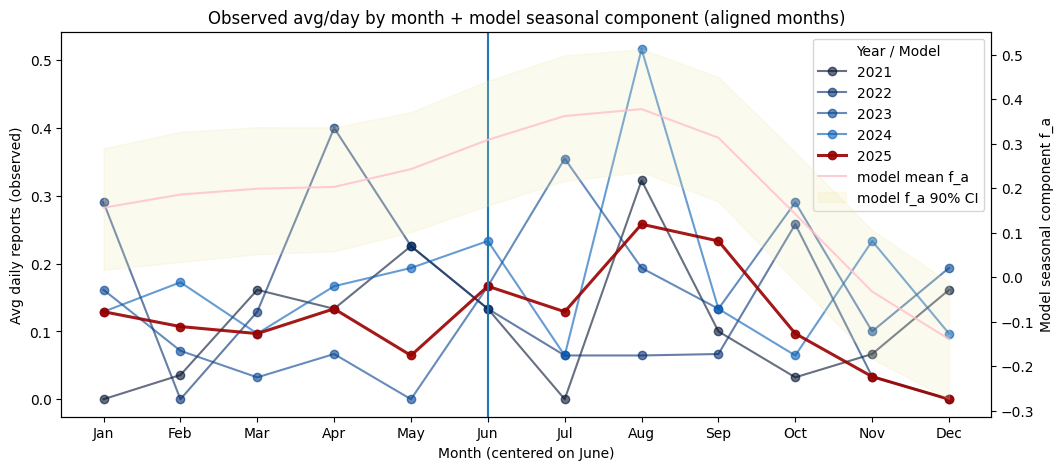

In [68]:

## Overlay 311 reports on the seasonal component
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

#obs = (
#    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
#                     df_plot["requested_"].dt.month.rename("month")])
#    .size()
#    .reset_index(name="n")
#)
#obs["days_in_month"] = pd.to_datetime(
#    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
#).dt.days_in_month
#obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
#obs["month_centered"] = obs["month"] - 6  # June=0

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

obs = monthly_counts.copy()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
# posterior
f_a_post = np.asarray(model.samples["f_a"])  # (n_draws, n_s)
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)

S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

# seasonal grid positions (0..S)
x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S   # same direction as package

# month boundaries in "days since Jan 1", scaled to the model's cycle length S
ref_year = 2021  # non-leap
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])  # 0..365
month_breaks = month_breaks / month_breaks[-1] * S               # rescale to 0..S

# assign each x_shift to a month bin 1..12
# digitize returns 1..len(breaks)-1, clip to 1..12
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

# sanity check: should contain all 1..12
print("Months present:", np.unique(grid_month))

# aggregate grid -> 12 months (NO empty slices now)
fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])

months_centered = np.arange(1, 13) - 6
# ----------------------------
# Plot: observed (left axis) + model f_a (right axis), SAME x
# ----------------------------
blue_family = {2021:"#01112f", 2022:"#012a6b", 2023:"#01408f", 2024:"#025bb5"}

fig, ax = plt.subplots(figsize=(12, 5))

# observed
for yr, g in obs.groupby("year"):
    if yr == 2025:
        ax.plot(g["month_centered"], g["avg_per_day"], marker="o",
                label=str(yr), color="#990000", alpha=0.9, linewidth=2.2)
    else:
        ax.plot(g["month_centered"], g["avg_per_day"], marker="o",
                label=str(yr), color=blue_family.get(yr, "#011f5b"),
                alpha=0.6, linewidth=1.5)

ax.axvline(0)
ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports (observed)")

# model (same x, different y) on twin y-axis only
ax2 = ax.twinx()
ax2.plot(months_centered, fa_mean_month, linewidth=1.5, color = "pink",alpha = 0.8,label="model mean f_a")
ax2.fill_between(months_centered, fa_lo_month, fa_hi_month, alpha=0.2, color= "palegoldenrod",label="model f_a 90% CI")
ax2.set_ylabel("Model seasonal component f_a")

# clean month tick labels on bottom axis
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

# legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, title="Year / Model", loc="upper right")

ax.set_title("Observed avg/day by month + model seasonal component (aligned months)")
plt.show()

## Intervention effect

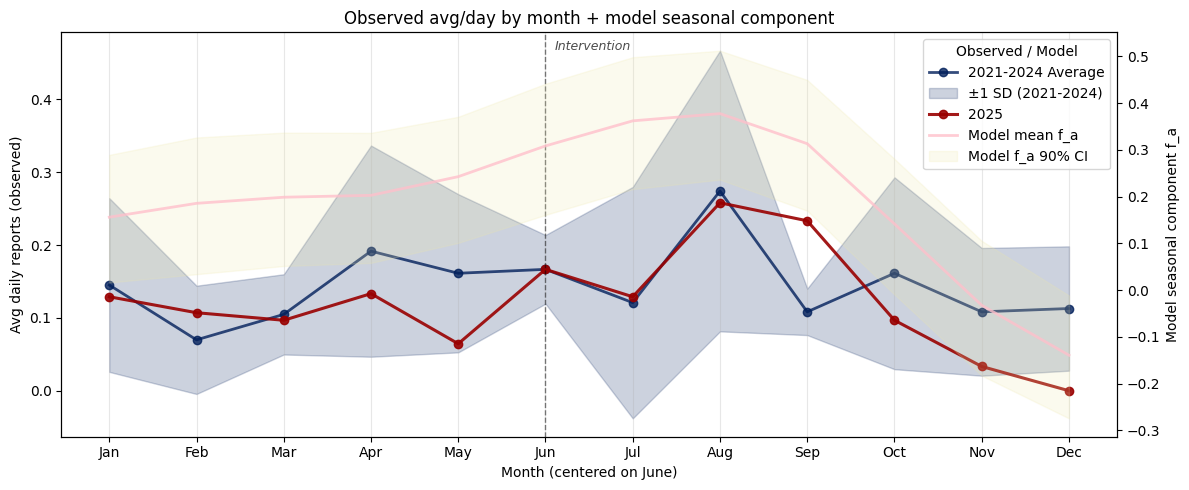

In [69]:
## Overlay 311 reports on the seasonal component
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

#obs = (
#    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
#                     df_plot["requested_"].dt.month.rename("month")])
#    .size()
#    .reset_index(name="n")
#)
#obs["days_in_month"] = pd.to_datetime(
#    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
#).dt.days_in_month
#obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
#obs["month_centered"] = obs["month"] - 6  # June=0

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

obs = monthly_counts.copy()

# Separate historical data from 2025
obs_historical = obs[obs["year"] < 2025]
obs_current = obs[obs["year"] == 2025]

# Compute mean and std by month across historical years
obs_summary = obs_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
# posterior
f_a_post = np.asarray(model.samples["f_a"])  # (n_draws, n_s)
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

# seasonal grid positions (0..S)
x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S   # same direction as package

# month boundaries in "days since Jan 1", scaled to the model's cycle length S
ref_year = 2021  # non-leap
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])  # 0..365
month_breaks = month_breaks / month_breaks[-1] * S               # rescale to 0..S

# assign each x_shift to a month bin 1..12
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

# aggregate grid -> 12 months
fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

# ----------------------------
# Plot: observed (left axis) + model f_a (right axis)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Plot historical average with confidence band
ax.plot(
    obs_summary["month_centered"],
    obs_summary["mean"],
    marker="o",
    label="2021-2024 Average",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
)
ax.fill_between(
    obs_summary["month_centered"],
    obs_summary["mean"] - obs_summary["std"],
    obs_summary["mean"] + obs_summary["std"],
    color="#011f5b",
    alpha=0.2,
    label="±1 SD (2021-2024)"
)

# Plot 2025 data
ax.plot(
    obs_current["month_centered"],
    obs_current["avg_per_day"],
    marker="o",
    label="2025",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
)

# Intervention line
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.text(0.1, ax.get_ylim()[1] * 0.95, "Intervention", 
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports (observed)")

# Model overlay on twin y-axis
ax2 = ax.twinx()
ax2.plot(
    months_centered,
    fa_mean_month,
    linewidth=2,
    color="pink",
    alpha=0.8,
    label="Model mean f_a"
)
ax2.fill_between(
    months_centered,
    fa_lo_month,
    fa_hi_month,
    alpha=0.2,
    color="palegoldenrod",
    label="Model f_a 90% CI"
)
ax2.set_ylabel("Model seasonal component f_a")

# Clean month tick labels
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    title="Observed / Model",
    loc="upper right"
)

ax.set_title("Observed avg/day by month + model seasonal component")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [37]:
## Overlay 311 reports on the seasonal component
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

#obs = (
#    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
#                     df_plot["requested_"].dt.month.rename("month")])
#    .size()
#    .reset_index(name="n")
#)
#obs["days_in_month"] = pd.to_datetime(
#    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
#).dt.days_in_month
#obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
#obs["month_centered"] = obs["month"] - 6  # June=0

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

obs = monthly_counts.copy()

# Separate historical data from 2025
obs_historical = obs[obs["year"] < 2025]
obs_current = obs[obs["year"] == 2025]

# Compute mean and std by month across historical years
obs_summary = obs_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
# posterior
f_a_post = np.asarray(model.samples["f_a"])  # (n_draws, n_s)
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

# seasonal grid positions (0..S)
x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S   # same direction as package

# month boundaries in "days since Jan 1", scaled to the model's cycle length S
ref_year = 2021  # non-leap
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])  # 0..365
month_breaks = month_breaks / month_breaks[-1] * S               # rescale to 0..S

# assign each x_shift to a month bin 1..12
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

# aggregate grid -> 12 months
fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

# ----------------------------
# Rescale model to match historical data (2021-2024 only)
# ----------------------------
# Fit: historical_data = scale * model + offset
# Use least squares to find best scale and offset
from scipy.optimize import curve_fit

def linear_transform(x, scale, offset):
    return scale * x + offset

# Fit model to historical average
popt, _ = curve_fit(
    linear_transform,
    fa_mean_month,
    obs_summary["mean"]
)
scale_fit, offset_fit = popt

# Apply transformation to model predictions
fa_mean_month_scaled = scale_fit * fa_mean_month + offset_fit
fa_lo_month_scaled = scale_fit * fa_lo_month + offset_fit
fa_hi_month_scaled = scale_fit * fa_hi_month + offset_fit

print(f"Model rescaling: scale={scale_fit:.3f}, offset={offset_fit:.3f}")

# ----------------------------
# Plot: observed + rescaled model (same axis)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Plot model first (as background)
ax.plot(
    months_centered,
    fa_mean_month_scaled,
    linewidth=2.5,
    color="pink",
    alpha=0.6,
    label="Model f_a (rescaled)",
    zorder=1
)
ax.fill_between(
    months_centered,
    fa_lo_month_scaled,
    fa_hi_month_scaled,
    alpha=0.15,
    color="palegoldenrod",
    label="Model f_a 90% CI",
    zorder=1
)

# Plot historical average with confidence band
ax.plot(
    obs_summary["month_centered"],
    obs_summary["mean"],
    marker="o",
    label="2021-2024 Average",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    zorder=3
)
#ax.fill_between(
#    obs_summary["month_centered"],
#    obs_summary["mean"] - obs_summary["std"],
#    obs_summary["mean"] + obs_summary["std"],
#    color="#011f5b",
#    alpha=0.2,
#    label="±1 SD (2021-2024)",
#    zorder=2
#)

# Plot 2025 data
ax.plot(
    obs_current["month_centered"],
    obs_current["avg_per_day"],
    marker="o",
    label="2025",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
    zorder=4
)

# Intervention line
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.text(0.1, ax.get_ylim()[1] * 0.95, "Intervention", 
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports")

# Clean month tick labels
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

ax.legend(loc="upper right")
ax.set_title("Observed avg/day by month + rescaled model seasonal component")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

Model rescaling: scale=0.145, offset=0.116


/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_77346/3082137574.py:129: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_current["residual"] = obs_current["avg_per_day"] - obs_current["month_centered"].map(model_baseline)


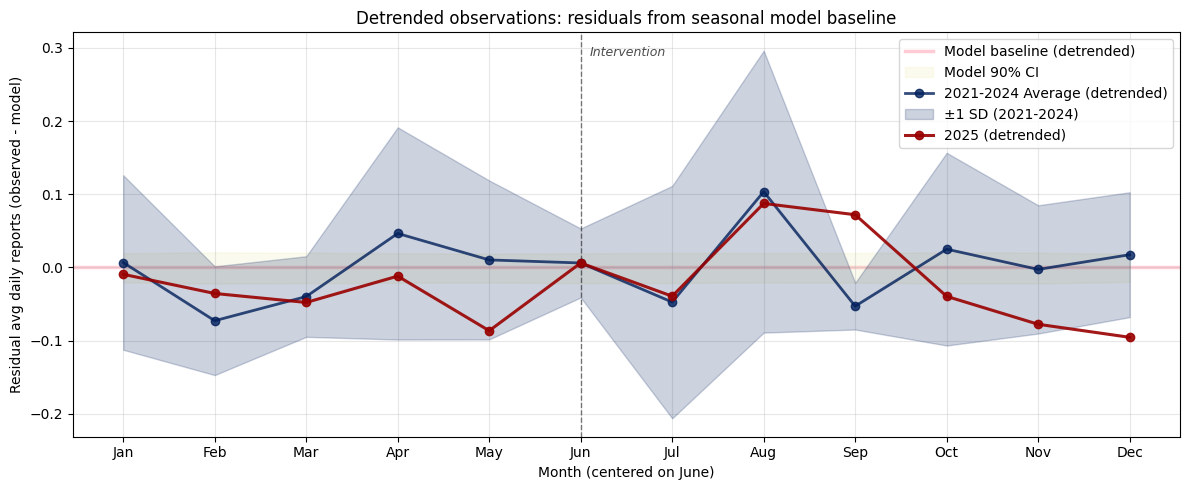

In [71]:
## Overlay 311 reports on the seasonal component
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

#obs = (
#    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
#                     df_plot["requested_"].dt.month.rename("month")])
#    .size()
#    .reset_index(name="n")
#)
#obs["days_in_month"] = pd.to_datetime(
#    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
#).dt.days_in_month
#obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
#obs["month_centered"] = obs["month"] - 6  # June=0

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

obs = monthly_counts.copy()


# Separate historical data from 2025
obs_historical = obs[obs["year"] < 2025]
obs_current = obs[obs["year"] == 2025]

# Compute mean and std by month across historical years
obs_summary = obs_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
# posterior
f_a_post = np.asarray(model.samples["f_a"])  # (n_draws, n_s)
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

# seasonal grid positions (0..S)
x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S   # same direction as package

# month boundaries in "days since Jan 1", scaled to the model's cycle length S
ref_year = 2021  # non-leap
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])  # 0..365
month_breaks = month_breaks / month_breaks[-1] * S               # rescale to 0..S

# assign each x_shift to a month bin 1..12
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

# aggregate grid -> 12 months
fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

# ----------------------------
# Rescale model to match historical data (2021-2024 only)
# ----------------------------
from scipy.optimize import curve_fit

def linear_transform(x, scale, offset):
    return scale * x + offset

# Fit model to historical average
popt, _ = curve_fit(
    linear_transform,
    fa_mean_month,
    obs_summary["mean"]
)
scale_fit, offset_fit = popt

# Apply transformation to model predictions
fa_mean_month_scaled = scale_fit * fa_mean_month + offset_fit
fa_lo_month_scaled = scale_fit * fa_lo_month + offset_fit
fa_hi_month_scaled = scale_fit * fa_hi_month + offset_fit

print(f"Model rescaling: scale={scale_fit:.3f}, offset={offset_fit:.3f}")

# ----------------------------
# De-trend: subtract fitted model mean from observations
# ----------------------------
# Create a mapping from month_centered to model prediction
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))
model_lo = dict(zip(months_centered, fa_lo_month_scaled))
model_hi = dict(zip(months_centered, fa_hi_month_scaled))

# Compute residuals for historical average
obs_summary["residual"] = obs_summary["mean"] - obs_summary["month_centered"].map(model_baseline)

# Compute residuals for 2025
obs_current["residual"] = obs_current["avg_per_day"] - obs_current["month_centered"].map(model_baseline)

# Model CI bands relative to zero
model_ci_lower = fa_lo_month_scaled - fa_mean_month_scaled
model_ci_upper = fa_hi_month_scaled - fa_mean_month_scaled

# ----------------------------
# Plot: detrended observations with model uncertainty
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Model baseline (zero line) with CI
ax.axhline(0, color="pink", linewidth=2.5, alpha=0.8, label="Model baseline (detrended)", zorder=1)
ax.fill_between(
    months_centered,
    model_ci_lower,
    model_ci_upper,
    alpha=0.2,
    color="palegoldenrod",
    label="Model 90% CI",
    zorder=1
)

# Plot historical average residuals with confidence band
ax.plot(
    obs_summary["month_centered"],
    obs_summary["residual"],
    marker="o",
    label="2021-2024 Average (detrended)",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    zorder=3
)
ax.fill_between(
    obs_summary["month_centered"],
    obs_summary["residual"] - obs_summary["std"],
    obs_summary["residual"] + obs_summary["std"],
    color="#011f5b",
    alpha=0.2,
    label="±1 SD (2021-2024)",
    zorder=2
)

# Plot 2025 residuals
ax.plot(
    obs_current["month_centered"],
    obs_current["residual"],
    marker="o",
    label="2025 (detrended)",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
    zorder=4
)

# Intervention line
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.text(0.1, ax.get_ylim()[1] * 0.9, "Intervention", 
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Residual avg daily reports (observed - model)")

# Clean month tick labels
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

ax.legend(loc="upper right")
ax.set_title("Detrended observations: residuals from seasonal model baseline")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Model rescaling: scale=0.141, offset=0.114


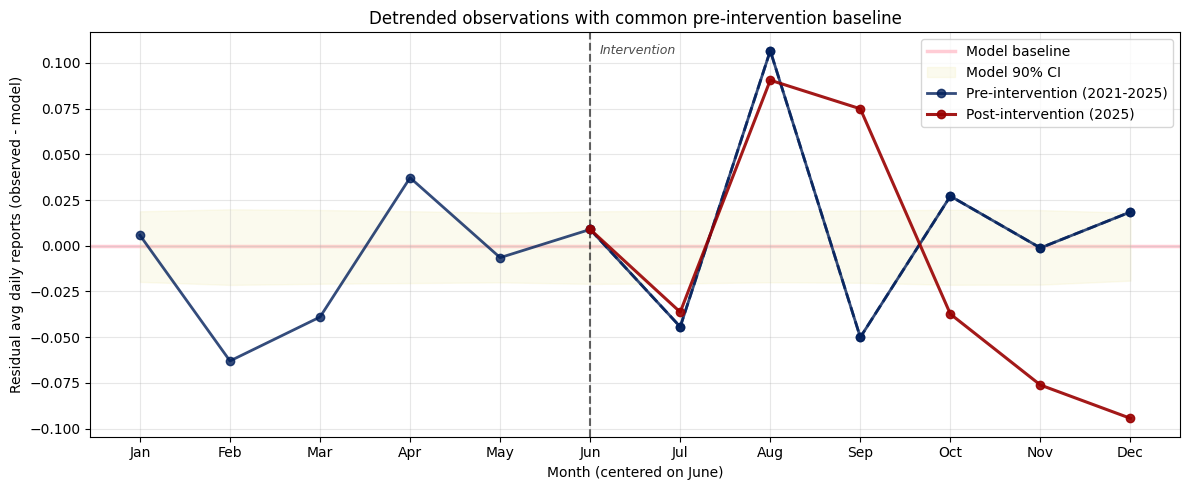

In [72]:
## VERSION 1: De-trended plot with merged pre-intervention baseline
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

#obs = (
#    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
#                     df_plot["requested_"].dt.month.rename("month")])
#    .size()
#    .reset_index(name="n")
#)
#obs["days_in_month"] = pd.to_datetime(
#    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
#).dt.days_in_month
#obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
#obs["month_centered"] = obs["month"] - 6  # June=0

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

obs = monthly_counts.copy()

# Split data: pre-intervention includes 2021-2024 + Jan-May 2025
obs_pre_intervention = obs[
    (obs["year"] < 2025) | 
    ((obs["year"] == 2025) & (obs["month"] < 6))
].copy()
obs_post_intervention_historical = obs[
    (obs["year"] < 2025) & (obs["month"] >= 6)
].copy()
obs_post_intervention_2025 = obs[
    (obs["year"] == 2025) & (obs["month"] >= 6)
].copy()

# Compute averages
pre_summary = obs_pre_intervention.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

post_historical_summary = obs_post_intervention_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
f_a_post = np.asarray(model.samples["f_a"])
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S

ref_year = 2021
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])
month_breaks = month_breaks / month_breaks[-1] * S

grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

# ----------------------------
# Rescale model to match pre-intervention data only
# ----------------------------
from scipy.optimize import curve_fit

def linear_transform(x, scale, offset):
    return scale * x + offset

# Fit model to pre-intervention average
popt, _ = curve_fit(
    linear_transform,
    fa_mean_month,
    pre_summary["mean"]
)
scale_fit, offset_fit = popt

fa_mean_month_scaled = scale_fit * fa_mean_month + offset_fit
fa_lo_month_scaled = scale_fit * fa_lo_month + offset_fit
fa_hi_month_scaled = scale_fit * fa_hi_month + offset_fit

print(f"Model rescaling: scale={scale_fit:.3f}, offset={offset_fit:.3f}")

# ----------------------------
# De-trend: subtract fitted model mean from observations
# ----------------------------
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

pre_summary["residual"] = pre_summary["mean"] - pre_summary["month_centered"].map(model_baseline)
post_historical_summary["residual"] = post_historical_summary["mean"] - post_historical_summary["month_centered"].map(model_baseline)
obs_post_intervention_2025["residual"] = obs_post_intervention_2025["avg_per_day"] - obs_post_intervention_2025["month_centered"].map(model_baseline)

model_ci_lower = fa_lo_month_scaled - fa_mean_month_scaled
model_ci_upper = fa_hi_month_scaled - fa_mean_month_scaled

# ----------------------------
# Plot: detrended with split at intervention
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Model baseline (zero line) with CI
ax.axhline(0, color="pink", linewidth=2.5, alpha=0.8, label="Model baseline", zorder=1)
ax.fill_between(
    months_centered,
    model_ci_lower,
    model_ci_upper,
    alpha=0.2,
    color="palegoldenrod",
    label="Model 90% CI",
    zorder=1
)

# Pre-intervention (merged baseline)
ax.plot(
    pre_summary["month_centered"],
    pre_summary["residual"],
    marker="o",
    label="Pre-intervention (2021-2025)",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    zorder=3
)
#ax.fill_between(
#    pre_summary["month_centered"],
#    pre_summary["residual"] - pre_summary["std"],
#    pre_summary["residual"] + pre_summary["std"],
#    color="#011f5b",
#    alpha=0.2,
#    zorder=2
#)

# Post-intervention: historical
ax.plot(
    post_historical_summary["month_centered"],
    post_historical_summary["residual"],
    marker="o",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    linestyle="--",
    zorder=3
)
#ax.fill_between(
#    post_historical_summary["month_centered"],
#    post_historical_summary["residual"] - post_historical_summary["std"],
#    post_historical_summary["residual"] + post_historical_summary["std"],
#    color="#011f5b",
#    alpha=0.2,
#    zorder=2
#)

# Post-intervention: 2025
ax.plot(
    obs_post_intervention_2025["month_centered"],
    obs_post_intervention_2025["residual"],
    marker="o",
    label="Post-intervention (2025)",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
    zorder=4
)

# Intervention line
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(0.1, ax.get_ylim()[1] * 0.9, "Intervention", 
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Residual avg daily reports (observed - model)")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

ax.legend(loc="upper right")
ax.set_title("Detrended observations with common pre-intervention baseline")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

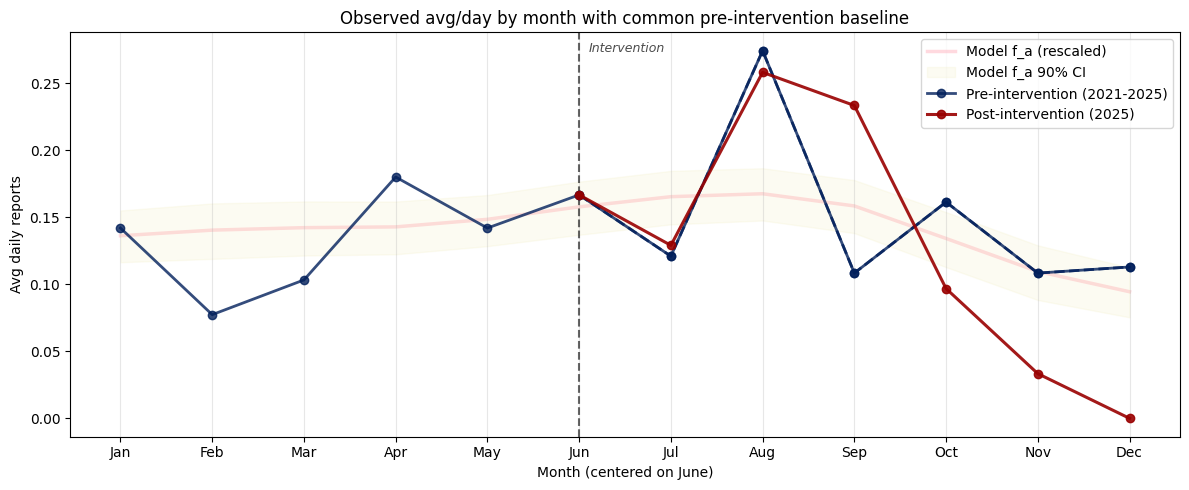

In [73]:
## VERSION 2: Trended plot with merged pre-intervention baseline
# (Uses same data processing as above)

fig, ax = plt.subplots(figsize=(12, 5))

# Model fit
ax.plot(
    months_centered,
    fa_mean_month_scaled,
    linewidth=2.5,
    color="pink",
    alpha=0.6,
    label="Model f_a (rescaled)",
    zorder=1
)
ax.fill_between(
    months_centered,
    fa_lo_month_scaled,
    fa_hi_month_scaled,
    alpha=0.15,
    color="palegoldenrod",
    label="Model f_a 90% CI",
    zorder=1
)

# Pre-intervention (merged baseline)
ax.plot(
    pre_summary["month_centered"],
    pre_summary["mean"],
    marker="o",
    label="Pre-intervention (2021-2025)",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    zorder=3
)
#ax.fill_between(
#    pre_summary["month_centered"],
#    pre_summary["mean"] - pre_summary["std"],
#    pre_summary["mean"] + pre_summary["std"],
#    color="#011f5b",
#    alpha=0.2,
#    zorder=2
#)

# Post-intervention: historical
ax.plot(
    post_historical_summary["month_centered"],
    post_historical_summary["mean"],
    marker="o",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    linestyle="--",
    zorder=3
)
#ax.fill_between(
#    post_historical_summary["month_centered"],
#    post_historical_summary["mean"] - post_historical_summary["std"],
#    post_historical_summary["mean"] + post_historical_summary["std"],
#    color="#011f5b",
#    alpha=0.2,
#    zorder=2
#)

# Post-intervention: 2025
ax.plot(
    obs_post_intervention_2025["month_centered"],
    obs_post_intervention_2025["avg_per_day"],
    marker="o",
    label="Post-intervention (2025)",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
    zorder=4
)

# Intervention line
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(0.1, ax.get_ylim()[1] * 0.95, "Intervention", 
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

ax.legend(loc="upper right")
ax.set_title("Observed avg/day by month with common pre-intervention baseline")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

INTERVENTION EFFECT ANALYSIS (Detrended Residuals)

Sample sizes:
  Pre-intervention (2021-2025 Jan-May):  n = 53
  Post-intervention (2025 Jun-Dec):       n = 7

Mean detrended residuals:
  Pre-intervention:    -0.001 reports/day (SD = 0.105)
  Post-intervention:   -0.010 reports/day (SD = 0.071)

Effect:
  Difference:          -0.009 reports/day
  95% CI:             [-0.077, 0.060]
  Cohen's d:           -0.086

Statistical test:
  t-statistic:         -0.286
  p-value:             0.7811
  Significance:       ns

Interpretation:
  Effect size:        negligible effect
  No significant change detected after intervention.


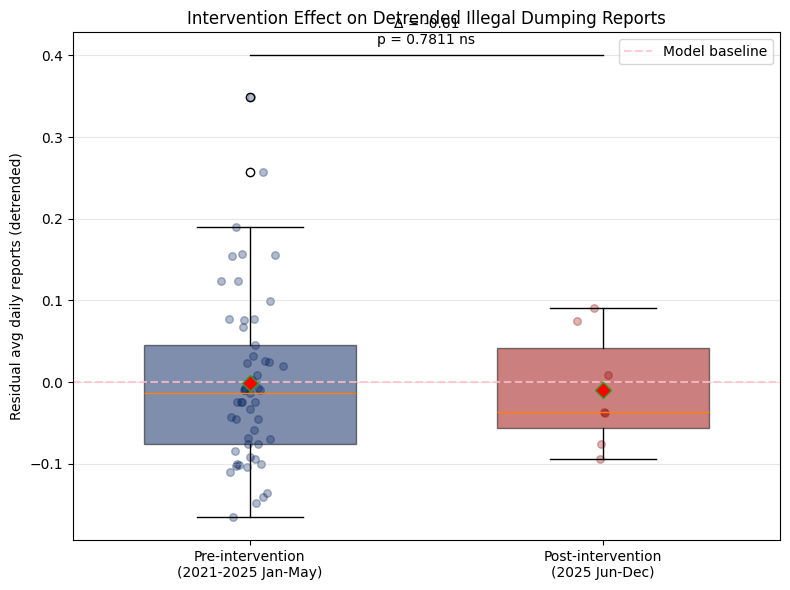

In [74]:
## Compute effect size and significance from detrended residuals
# ----------------------------
# Get all individual detrended observations (not just monthly averages)
# ----------------------------

# Create model baseline mapping
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

# Add residuals to all observations
obs["residual"] = obs["avg_per_day"] - obs["month_centered"].map(model_baseline)

# Split into pre and post intervention periods
pre_intervention_residuals = obs[
    (obs["year"] < 2025) | 
    ((obs["year"] == 2025) & (obs["month"] < 6))
]["residual"].values

post_intervention_residuals = obs[
    (obs["year"] == 2025) & (obs["month"] >= 6)
]["residual"].values

# ----------------------------
# Compute statistics
# ----------------------------
from scipy import stats

# Means
pre_mean = np.mean(pre_intervention_residuals)
post_mean = np.mean(post_intervention_residuals)
diff_means = post_mean - pre_mean

# Standard deviations
pre_std = np.std(pre_intervention_residuals, ddof=1)
post_std = np.std(post_intervention_residuals, ddof=1)

# Effect size (Cohen's d)
pooled_std = np.sqrt(
    ((len(pre_intervention_residuals) - 1) * pre_std**2 + 
     (len(post_intervention_residuals) - 1) * post_std**2) / 
    (len(pre_intervention_residuals) + len(post_intervention_residuals) - 2)
)
cohens_d = diff_means / pooled_std

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(
    post_intervention_residuals,
    pre_intervention_residuals,
    equal_var=False  # Welch's t-test (more robust)
)

# 95% Confidence interval for difference in means
se_diff = np.sqrt(
    pre_std**2 / len(pre_intervention_residuals) + 
    post_std**2 / len(post_intervention_residuals)
)
df_welch = (
    (pre_std**2 / len(pre_intervention_residuals) + 
     post_std**2 / len(post_intervention_residuals))**2 /
    ((pre_std**2 / len(pre_intervention_residuals))**2 / (len(pre_intervention_residuals) - 1) +
     (post_std**2 / len(post_intervention_residuals))**2 / (len(post_intervention_residuals) - 1))
)
t_crit = stats.t.ppf(0.975, df_welch)
ci_lower = diff_means - t_crit * se_diff
ci_upper = diff_means + t_crit * se_diff

# ----------------------------
# Print results
# ----------------------------
print("=" * 60)
print("INTERVENTION EFFECT ANALYSIS (Detrended Residuals)")
print("=" * 60)
print(f"\nSample sizes:")
print(f"  Pre-intervention (2021-2025 Jan-May):  n = {len(pre_intervention_residuals)}")
print(f"  Post-intervention (2025 Jun-Dec):       n = {len(post_intervention_residuals)}")
print(f"\nMean detrended residuals:")
print(f"  Pre-intervention:   {pre_mean:>7.3f} reports/day (SD = {pre_std:.3f})")
print(f"  Post-intervention:  {post_mean:>7.3f} reports/day (SD = {post_std:.3f})")
print(f"\nEffect:")
print(f"  Difference:         {diff_means:>7.3f} reports/day")
print(f"  95% CI:             [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  Cohen's d:          {cohens_d:>7.3f}")
print(f"\nStatistical test:")
print(f"  t-statistic:        {t_stat:>7.3f}")
print(f"  p-value:            {p_value:>7.4f}")
print(f"  Significance:       {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
print("\nInterpretation:")
if cohens_d < -0.2:
    effect_interp = "small decrease"
elif cohens_d < -0.5:
    effect_interp = "medium decrease"
elif cohens_d < -0.8:
    effect_interp = "large decrease"
elif cohens_d > 0.8:
    effect_interp = "large increase"
elif cohens_d > 0.5:
    effect_interp = "medium increase"
elif cohens_d > 0.2:
    effect_interp = "small increase"
else:
    effect_interp = "negligible effect"
    
print(f"  Effect size:        {effect_interp}")
if p_value < 0.05:
    direction = "decreased" if diff_means < 0 else "increased"
    print(f"  The intervention significantly {direction} illegal dumping reports")
    print(f"  after accounting for seasonal patterns.")
else:
    print(f"  No significant change detected after intervention.")
print("=" * 60)

# ----------------------------
# Optional: Visualization of the effect
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

positions = [1, 2]
data_to_plot = [pre_intervention_residuals, post_intervention_residuals]
labels = ['Pre-intervention\n(2021-2025 Jan-May)', 'Post-intervention\n(2025 Jun-Dec)']

# Box plot
bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Color the boxes
bp['boxes'][0].set_facecolor('#011f5b')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('#990000')
bp['boxes'][1].set_alpha(0.5)

# Add individual points
for i, (pos, data) in enumerate(zip(positions, data_to_plot)):
    x = np.random.normal(pos, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.3, s=30, 
               color='#011f5b' if i == 0 else '#990000')

# Add effect annotation
y_max = max(np.max(pre_intervention_residuals), np.max(post_intervention_residuals))
y_min = min(np.min(pre_intervention_residuals), np.min(post_intervention_residuals))
y_range = y_max - y_min
y_annot = y_max + 0.1 * y_range

ax.plot([1, 2], [y_annot, y_annot], 'k-', linewidth=1)
sig_marker = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
ax.text(1.5, y_annot + 0.02 * y_range, 
        f'Δ = {diff_means:.2f}\np = {p_value:.4f} {sig_marker}',
        ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='pink', linestyle='--', linewidth=1.5, alpha=0.8, label='Model baseline')
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Residual avg daily reports (detrended)')
ax.set_title('Intervention Effect on Detrended Illegal Dumping Reports')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

MONTH-BY-MONTH INTERVENTION EFFECT ANALYSIS (Detrended Residuals)

Comparing 2025 post-intervention months to historical (2021-2024) same-month averages

--------------------------------------------------------------------------------
Month    N_hist  Hist_Mean  2025       Diff       Cohen_d    p-value    Sig  
--------------------------------------------------------------------------------
Jun      4           0.009     0.009    -0.000    -0.000    1.0000      
Jul      4          -0.044    -0.036     0.008     0.051    0.9595      
Aug      4           0.107     0.091    -0.016    -0.084    0.9333      
Sep      4          -0.050     0.075     0.125     3.917    0.0001 ***  
Oct      4           0.027    -0.037    -0.065    -0.490    0.6242      
Nov      4          -0.001    -0.076    -0.075    -0.856    0.3923      
Dec      4           0.018    -0.094    -0.113    -1.323    0.1859      
--------------------------------------------------------------------------------

OVERALL EFFEC

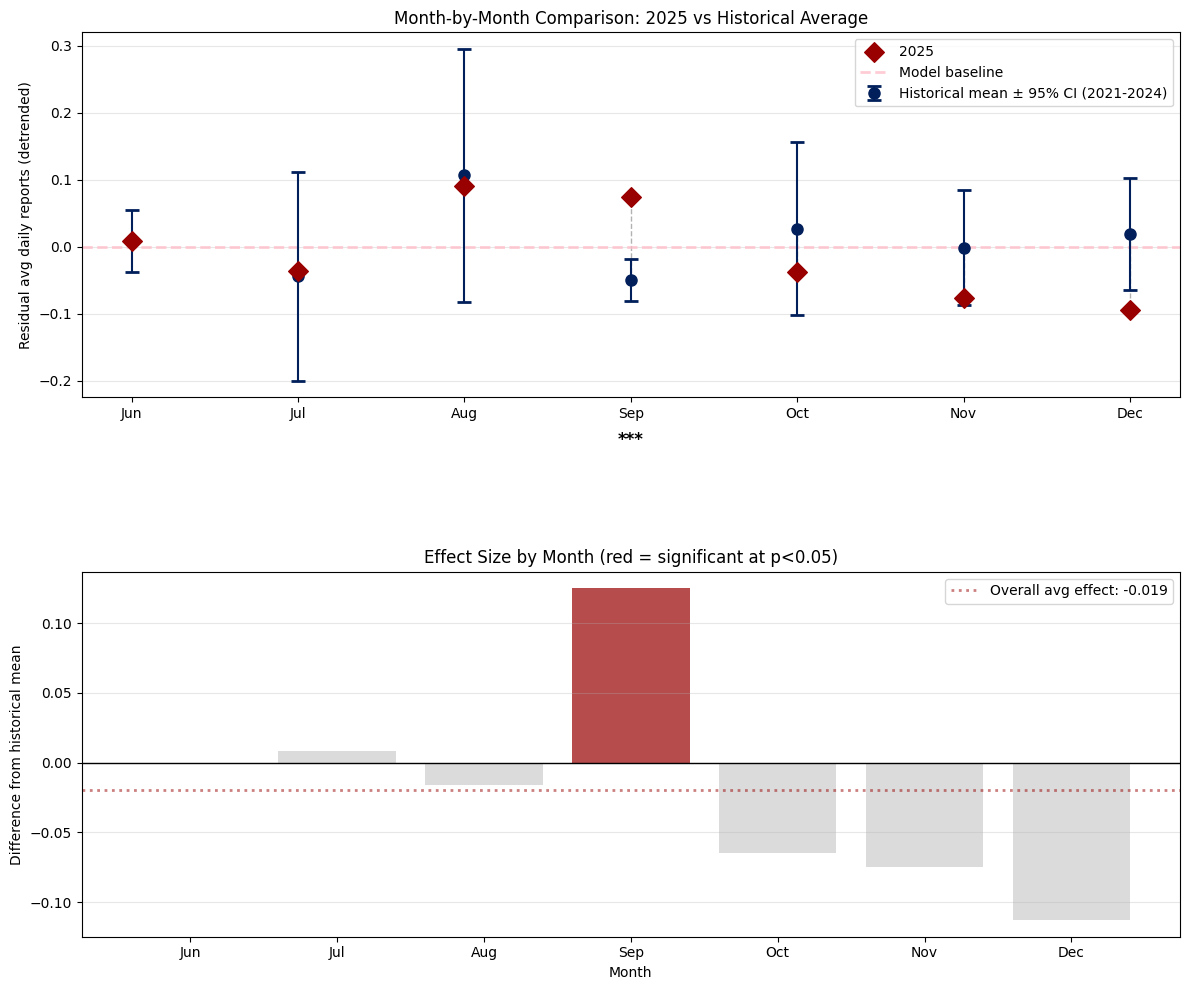


Detailed results table:
 month month_name  month_centered  n_historical  historical_mean  historical_std  ci_lower  ci_upper  value_2025    difference      cohens_d       z_score  p_value
     6        Jun               0             4         0.008925        0.047140 -0.037273  0.055123    0.008925 -6.938894e-18 -1.471962e-16 -1.471962e-16 1.000000
     7        Jul               1             4        -0.044357        0.158853 -0.200033  0.111318   -0.036293  8.064516e-03  5.076731e-02  5.076731e-02 0.959511
     8        Aug               2             4         0.106680        0.192650 -0.082117  0.295477    0.090551 -1.612903e-02 -8.372184e-02 -8.372184e-02 0.933278
     9        Sep               3             4        -0.050086        0.031914 -0.081362 -0.018810    0.074914  1.250000e-01  3.916747e+00  3.916747e+00 0.000090
    10        Oct               4             4         0.027143        0.131693 -0.101916  0.156202   -0.037373 -6.451613e-02 -4.898979e-01 -4.898979e-01 

In [75]:
## Compute effect size and significance from detrended residuals
## Month-by-month comparison
# ----------------------------
# Get all individual detrended observations
# ----------------------------

# Create model baseline mapping
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

# Add residuals to all observations
obs["residual"] = obs["avg_per_day"] - obs["month_centered"].map(model_baseline)

# Split into pre and post intervention periods
obs_historical = obs[obs["year"] < 2025].copy()
obs_2025_post = obs[(obs["year"] == 2025) & (obs["month"] >= 6)].copy()

# ----------------------------
# Month-by-month comparisons
# ----------------------------
from scipy import stats

results = []

for month in range(6, 13):  # June through December
    month_centered = month - 6
    
    # Get historical values for this month
    historical_values = obs_historical[obs_historical["month"] == month]["residual"].values
    
    # Get 2025 value for this month
    current_value = obs_2025_post[obs_2025_post["month"] == month]["residual"].values
    
    if len(current_value) == 0:
        continue  # Skip if no 2025 data for this month yet
    
    current_value = current_value[0]  # Single observation for 2025
    
    # Calculate statistics
    hist_mean = np.mean(historical_values)
    hist_std = np.std(historical_values, ddof=1)
    diff = current_value - hist_mean
    
    # Cohen's d
    cohens_d = diff / hist_std if hist_std > 0 else np.nan
    
    # One-sample t-test: is 2025 different from historical mean?
    # (or z-score if we treat historical as population)
    z_score = diff / hist_std if hist_std > 0 else np.nan
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score))) if not np.isnan(z_score) else np.nan
    
    # 95% CI for historical mean
    se = hist_std / np.sqrt(len(historical_values))
    ci_lower = hist_mean - 1.96 * se
    ci_upper = hist_mean + 1.96 * se
    
    results.append({
        'month': month,
        'month_name': calendar.month_abbr[month],
        'month_centered': month_centered,
        'n_historical': len(historical_values),
        'historical_mean': hist_mean,
        'historical_std': hist_std,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'value_2025': current_value,
        'difference': diff,
        'cohens_d': cohens_d,
        'z_score': z_score,
        'p_value': p_value
    })

results_df = pd.DataFrame(results)

# Overall effect: average across months
overall_diff = results_df['difference'].mean()
overall_cohens_d = results_df['cohens_d'].mean()
# Combined p-value using Stouffer's method
z_combined = results_df['z_score'].sum() / np.sqrt(len(results_df))
p_combined = 2 * (1 - stats.norm.cdf(abs(z_combined)))

# ----------------------------
# Print results
# ----------------------------
print("=" * 80)
print("MONTH-BY-MONTH INTERVENTION EFFECT ANALYSIS (Detrended Residuals)")
print("=" * 80)
print("\nComparing 2025 post-intervention months to historical (2021-2024) same-month averages")
print("\n" + "-" * 80)
print(f"{'Month':<8} {'N_hist':<7} {'Hist_Mean':<10} {'2025':<10} {'Diff':<10} {'Cohen_d':<10} {'p-value':<10} {'Sig':<5}")
print("-" * 80)

for _, row in results_df.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
    print(f"{row['month_name']:<8} {row['n_historical']:<7.0f} {row['historical_mean']:>9.3f} {row['value_2025']:>9.3f} "
          f"{row['difference']:>9.3f} {row['cohens_d']:>9.3f} {row['p_value']:>9.4f} {sig:<5}")

print("-" * 80)
print(f"\nOVERALL EFFECT (average across post-intervention months):")
print(f"  Mean difference:    {overall_diff:>7.3f} reports/day")
print(f"  Mean Cohen's d:     {overall_cohens_d:>7.3f}")
print(f"  Combined p-value:   {p_combined:>7.4f} (Stouffer's method)")
print(f"  Significance:       {'***' if p_combined < 0.001 else '**' if p_combined < 0.01 else '*' if p_combined < 0.05 else 'ns'}")

print("\nInterpretation:")
if abs(overall_cohens_d) < 0.2:
    effect_interp = "negligible effect"
elif abs(overall_cohens_d) < 0.5:
    effect_interp = "small effect"
elif abs(overall_cohens_d) < 0.8:
    effect_interp = "medium effect"
else:
    effect_interp = "large effect"
    
print(f"  Effect size:        {effect_interp}")
if p_combined < 0.05:
    direction = "decreased" if overall_diff < 0 else "increased"
    print(f"  The intervention significantly {direction} illegal dumping reports")
    print(f"  after accounting for seasonal patterns (month-by-month comparison).")
else:
    print(f"  No significant change detected after intervention.")
print("=" * 80)

# ----------------------------
# Visualization
# ----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel 1: Month-by-month comparison
month_names = results_df['month_name'].values
x_pos = np.arange(len(month_names))

# Historical means with error bars
ax1.errorbar(x_pos, results_df['historical_mean'], 
             yerr=1.96 * results_df['historical_std'] / np.sqrt(results_df['n_historical']),
             fmt='o', color='#011f5b', markersize=8, capsize=5, capthick=2,
             label='Historical mean ± 95% CI (2021-2024)', zorder=3)

# 2025 values
ax1.scatter(x_pos, results_df['value_2025'], 
           color='#990000', s=100, marker='D', label='2025', zorder=4)

# Connect with lines to show difference
for i, (hist, curr) in enumerate(zip(results_df['historical_mean'], results_df['value_2025'])):
    ax1.plot([i, i], [hist, curr], 'k--', alpha=0.3, linewidth=1)

ax1.axhline(0, color='pink', linestyle='--', linewidth=2, alpha=0.8, label='Model baseline')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Residual avg daily reports (detrended)')
ax1.set_title('Month-by-Month Comparison: 2025 vs Historical Average')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Effect sizes and significance
colors = ['#990000' if p < 0.05 else '#cccccc' for p in results_df['p_value']]
bars = ax2.bar(x_pos, results_df['difference'], color=colors, alpha=0.7)

# Add significance stars
for i, row in results_df.iterrows():
    if row['p_value'] < 0.001:
        sig = '***'
    elif row['p_value'] < 0.01:
        sig = '**'
    elif row['p_value'] < 0.05:
        sig = '*'
    else:
        sig = ''
    
    if sig:
        y_pos = row['difference'] + (0.1 if row['difference'] > 0 else -0.1)
        ax2.text(i, y_pos, sig, ha='center', va='bottom' if row['difference'] > 0 else 'top',
                fontsize=12, fontweight='bold')

ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(month_names)
ax2.set_ylabel('Difference from historical mean')
ax2.set_xlabel('Month')
ax2.set_title('Effect Size by Month (red = significant at p<0.05)')
ax2.grid(True, alpha=0.3, axis='y')

# Add overall effect line
ax2.axhline(overall_diff, color='#990000', linestyle=':', linewidth=2, 
           alpha=0.5, label=f'Overall avg effect: {overall_diff:.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Export results table
# ----------------------------
print("\nDetailed results table:")
print(results_df.to_string(index=False))

INTERVENTION EFFECT ANALYSIS
Month-by-month differences aggregated into single statistic

Method: For each post-intervention month (Jun-Dec 2025), compute difference
        from historical average for that same month (2021-2024).
        Then test if mean difference across months is significantly non-zero.

--------------------------------------------------------------------------------

Monthly differences (2025 - Historical mean):
  Jun:   -0.000 reports/day
  Jul:    0.008 reports/day
  Aug:   -0.016 reports/day
  Sep:    0.125 reports/day
  Oct:   -0.065 reports/day
  Nov:   -0.075 reports/day
  Dec:   -0.113 reports/day

--------------------------------------------------------------------------------
AGGREGATE EFFECT ACROSS MONTHS:
--------------------------------------------------------------------------------
  Number of months:        7
  Mean difference:          -0.019 reports/day
  Std of differences:        0.077
  95% CI:                  [-0.091, 0.052]
  Cohen's d:     

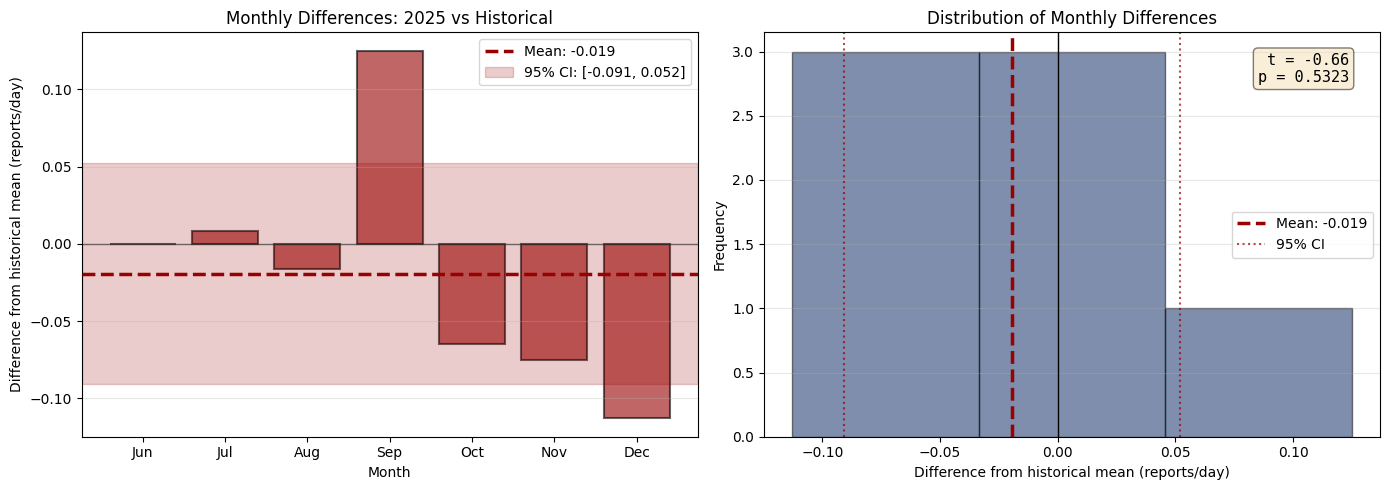

In [76]:
## Compute effect size and significance from detrended residuals
## Month-by-month differences, then aggregate
# ----------------------------
# Get all individual detrended observations
# ----------------------------

# Create model baseline mapping
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

# Add residuals to all observations
obs["residual"] = obs["avg_per_day"] - obs["month_centered"].map(model_baseline)

# Split into pre and post intervention periods
obs_historical = obs[obs["year"] < 2025].copy()
obs_2025_post = obs[(obs["year"] == 2025) & (obs["month"] >= 6)].copy()

# ----------------------------
# Compute month-by-month differences
# ----------------------------
from scipy import stats

monthly_differences = []

for month in range(6, 13):  # June through December
    # Get historical values for this month
    historical_values = obs_historical[obs_historical["month"] == month]["residual"].values
    
    # Get 2025 value for this month
    current_value = obs_2025_post[obs_2025_post["month"] == month]["residual"].values
    
    if len(current_value) == 0 or len(historical_values) == 0:
        continue  # Skip if no data
    
    current_value = current_value[0]  # Single observation for 2025
    hist_mean = np.mean(historical_values)
    
    # The difference for this month
    diff = current_value - hist_mean
    monthly_differences.append(diff)

# Convert to array
monthly_differences = np.array(monthly_differences)

# ----------------------------
# Aggregate statistics across months
# ----------------------------

# Mean difference across months
mean_diff = np.mean(monthly_differences)
std_diff = np.std(monthly_differences, ddof=1)
se_diff = std_diff / np.sqrt(len(monthly_differences))

# One-sample t-test: are the monthly differences significantly different from zero?
t_stat, p_value = stats.ttest_1samp(monthly_differences, 0)

# 95% CI for mean difference
ci_lower = mean_diff - stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff
ci_upper = mean_diff + stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff

# Effect size: mean difference divided by std of differences
cohens_d = mean_diff / std_diff if std_diff > 0 else np.nan

# ----------------------------
# Print results
# ----------------------------
print("=" * 80)
print("INTERVENTION EFFECT ANALYSIS")
print("Month-by-month differences aggregated into single statistic")
print("=" * 80)
print(f"\nMethod: For each post-intervention month (Jun-Dec 2025), compute difference")
print(f"        from historical average for that same month (2021-2024).")
print(f"        Then test if mean difference across months is significantly non-zero.")
print("\n" + "-" * 80)

print(f"\nMonthly differences (2025 - Historical mean):")
month_names = [calendar.month_abbr[m] for m in range(6, 6 + len(monthly_differences))]
for month_name, diff in zip(month_names, monthly_differences):
    print(f"  {month_name}: {diff:>8.3f} reports/day")

print("\n" + "-" * 80)
print(f"AGGREGATE EFFECT ACROSS MONTHS:")
print("-" * 80)
print(f"  Number of months:        {len(monthly_differences)}")
print(f"  Mean difference:         {mean_diff:>7.3f} reports/day")
print(f"  Std of differences:      {std_diff:>7.3f}")
print(f"  95% CI:                  [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  Cohen's d:               {cohens_d:>7.3f}")
print(f"\n  t-statistic:             {t_stat:>7.3f}")
print(f"  p-value:                 {p_value:>7.4f}")
print(f"  Significance:            {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\nInterpretation:")
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"
    
print(f"  Effect size:             {effect_interp}")

if p_value < 0.05:
    direction = "decreased" if mean_diff < 0 else "increased"
    print(f"\n  ✓ The intervention significantly {direction} illegal dumping reports")
    print(f"    by an average of {abs(mean_diff):.3f} reports/day per month,")
    print(f"    after accounting for seasonal patterns.")
    
    # Percentage change (relative to typical scale)
    typical_scale = np.mean([np.mean(obs_historical[obs_historical["month"] == m]["avg_per_day"]) 
                            for m in range(6, 13) if len(obs_historical[obs_historical["month"] == m]) > 0])
    pct_change = (mean_diff / typical_scale) * 100 if typical_scale > 0 else np.nan
    if not np.isnan(pct_change):
        print(f"    This represents approximately a {pct_change:.1f}% change.")
else:
    print(f"\n  ✗ No significant change detected after intervention.")
    print(f"    Mean difference of {mean_diff:.3f} reports/day could be due to chance")
    print(f"    (p = {p_value:.4f}).")

print("=" * 80)

# ----------------------------
# Visualization
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Individual monthly differences
x_pos = np.arange(len(monthly_differences))
colors = ['#990000' if mean_diff < 0 else '#011f5b' for _ in monthly_differences]

bars = ax1.bar(x_pos, monthly_differences, color=colors, alpha=0.6, edgecolor='black', linewidth=1.5)

# Mean line
ax1.axhline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}', zorder=5)

# Confidence interval band
ax1.axhspan(ci_lower, ci_upper, alpha=0.2, color='#990000', 
           label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')

# Zero line
ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Difference from historical mean (reports/day)')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Differences: 2025 vs Historical')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Distribution and inference
# Show the differences as a distribution with test result
ax2.hist(monthly_differences, bins=max(3, len(monthly_differences)//2), 
         color='#011f5b', alpha=0.5, edgecolor='black')

# Add mean and CI
ax2.axvline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}')
ax2.axvline(ci_lower, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(ci_upper, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'95% CI')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)

# Add test result text
sig_text = f"t = {t_stat:.2f}\np = {p_value:.4f}"
if p_value < 0.001:
    sig_text += "\n***"
elif p_value < 0.01:
    sig_text += "\n**"
elif p_value < 0.05:
    sig_text += "\n*"

ax2.text(0.95, 0.95, sig_text, transform=ax2.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11, fontfamily='monospace')

ax2.set_xlabel('Difference from historical mean (reports/day)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Monthly Differences')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

INTERVENTION EFFECT ANALYSIS (EXCLUDING SEPTEMBER)
Month-by-month differences aggregated into single statistic

Method: For each post-intervention month (Jun-Dec 2025, EXCEPT SEP), compute
        difference from historical average for that same month (2021-2024).
        Then test if mean difference across months is significantly non-zero.

--------------------------------------------------------------------------------

Monthly differences (2025 - Historical mean):
  Jun:   -0.000 reports/day
  Jul:    0.008 reports/day
  Aug:   -0.016 reports/day
  Oct:   -0.065 reports/day
  Nov:   -0.075 reports/day
  Dec:   -0.113 reports/day
  Sep: EXCLUDED (outlier)

--------------------------------------------------------------------------------
AGGREGATE EFFECT ACROSS MONTHS (excluding September):
--------------------------------------------------------------------------------
  Number of months:        6
  Mean difference:          -0.043 reports/day
  Std of differences:        0.048
  95% 

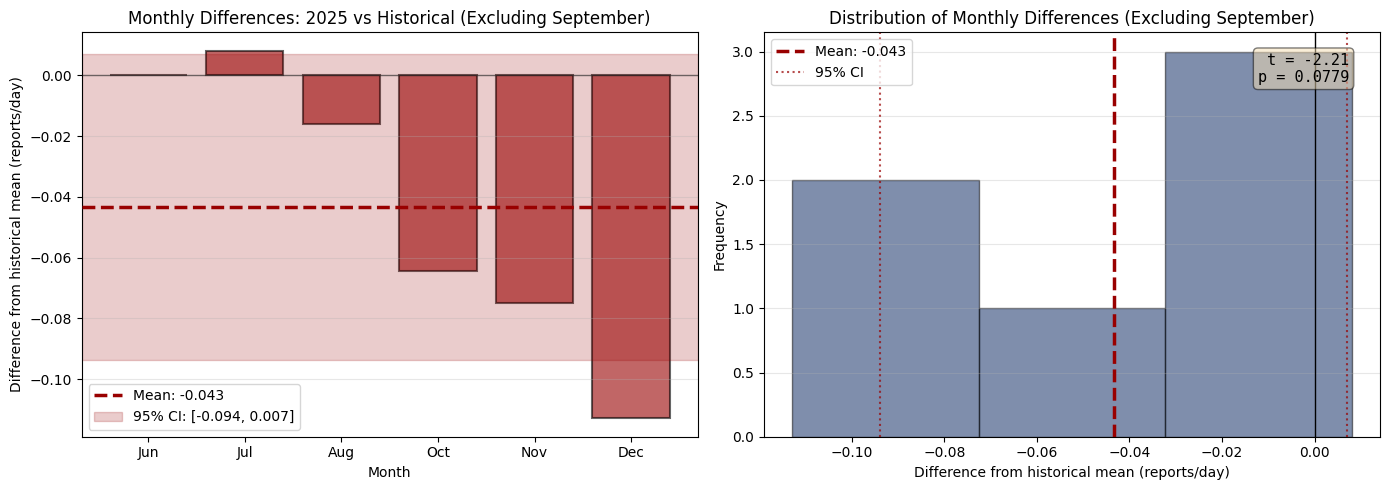


SENSITIVITY ANALYSIS: Impact of excluding September

With September included:
  Mean difference:   -0.019 reports/day
  t-statistic:       -0.662
  p-value:           0.5323

Without September:
  Mean difference:   -0.043 reports/day
  t-statistic:       -2.212
  p-value:           0.0779

Change from excluding September:
  Δ Mean:            -0.024
  Δ t-stat:          -1.550
  Δ p-value:        -0.4545


In [77]:
## Compute effect size and significance from detrended residuals
## Month-by-month differences, then aggregate (EXCLUDING SEPTEMBER)
# ----------------------------
# Get all individual detrended observations
# ----------------------------

# Create model baseline mapping
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

# Add residuals to all observations
obs["residual"] = obs["avg_per_day"] - obs["month_centered"].map(model_baseline)

# Split into pre and post intervention periods
obs_historical = obs[obs["year"] < 2025].copy()
obs_2025_post = obs[(obs["year"] == 2025) & (obs["month"] >= 6)].copy()

# ----------------------------
# Compute month-by-month differences (EXCLUDING SEPTEMBER)
# ----------------------------
from scipy import stats

monthly_differences = []
month_names_included = []

for month in range(6, 13):  # June through December
    # SKIP SEPTEMBER (month 9)
    if month == 9:
        continue
    
    # Get historical values for this month
    historical_values = obs_historical[obs_historical["month"] == month]["residual"].values
    
    # Get 2025 value for this month
    current_value = obs_2025_post[obs_2025_post["month"] == month]["residual"].values
    
    if len(current_value) == 0 or len(historical_values) == 0:
        continue  # Skip if no data
    
    current_value = current_value[0]  # Single observation for 2025
    hist_mean = np.mean(historical_values)
    
    # The difference for this month
    diff = current_value - hist_mean
    monthly_differences.append(diff)
    month_names_included.append(calendar.month_abbr[month])

# Convert to array
monthly_differences = np.array(monthly_differences)

# ----------------------------
# Aggregate statistics across months
# ----------------------------

# Mean difference across months
mean_diff = np.mean(monthly_differences)
std_diff = np.std(monthly_differences, ddof=1)
se_diff = std_diff / np.sqrt(len(monthly_differences))

# One-sample t-test: are the monthly differences significantly different from zero?
t_stat, p_value = stats.ttest_1samp(monthly_differences, 0)

# 95% CI for mean difference
ci_lower = mean_diff - stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff
ci_upper = mean_diff + stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff

# Effect size: mean difference divided by std of differences
cohens_d = mean_diff / std_diff if std_diff > 0 else np.nan

# ----------------------------
# Print results
# ----------------------------
print("=" * 80)
print("INTERVENTION EFFECT ANALYSIS (EXCLUDING SEPTEMBER)")
print("Month-by-month differences aggregated into single statistic")
print("=" * 80)
print(f"\nMethod: For each post-intervention month (Jun-Dec 2025, EXCEPT SEP), compute")
print(f"        difference from historical average for that same month (2021-2024).")
print(f"        Then test if mean difference across months is significantly non-zero.")
print("\n" + "-" * 80)

print(f"\nMonthly differences (2025 - Historical mean):")
for month_name, diff in zip(month_names_included, monthly_differences):
    print(f"  {month_name}: {diff:>8.3f} reports/day")
print(f"  Sep: EXCLUDED (outlier)")

print("\n" + "-" * 80)
print(f"AGGREGATE EFFECT ACROSS MONTHS (excluding September):")
print("-" * 80)
print(f"  Number of months:        {len(monthly_differences)}")
print(f"  Mean difference:         {mean_diff:>7.3f} reports/day")
print(f"  Std of differences:      {std_diff:>7.3f}")
print(f"  95% CI:                  [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  Cohen's d:               {cohens_d:>7.3f}")
print(f"\n  t-statistic:             {t_stat:>7.3f}")
print(f"  p-value:                 {p_value:>7.4f}")
print(f"  Significance:            {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\nInterpretation:")
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"
    
print(f"  Effect size:             {effect_interp}")

if p_value < 0.05:
    direction = "decreased" if mean_diff < 0 else "increased"
    print(f"\n  ✓ The intervention significantly {direction} illegal dumping reports")
    print(f"    by an average of {abs(mean_diff):.3f} reports/day per month,")
    print(f"    after accounting for seasonal patterns (excluding September outlier).")
    
    # Percentage change (relative to typical scale)
    typical_scale = np.mean([np.mean(obs_historical[obs_historical["month"] == m]["avg_per_day"]) 
                            for m in range(6, 13) if m != 9 and len(obs_historical[obs_historical["month"] == m]) > 0])
    pct_change = (mean_diff / typical_scale) * 100 if typical_scale > 0 else np.nan
    if not np.isnan(pct_change):
        print(f"    This represents approximately a {pct_change:.1f}% change.")
else:
    print(f"\n  ✗ No significant change detected after intervention.")
    print(f"    Mean difference of {mean_diff:.3f} reports/day could be due to chance")
    print(f"    (p = {p_value:.4f}).")

print("=" * 80)

# ----------------------------
# Visualization
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Individual monthly differences
x_pos = np.arange(len(monthly_differences))
colors = ['#990000' if mean_diff < 0 else '#011f5b' for _ in monthly_differences]

bars = ax1.bar(x_pos, monthly_differences, color=colors, alpha=0.6, edgecolor='black', linewidth=1.5)

# Mean line
ax1.axhline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}', zorder=5)

# Confidence interval band
ax1.axhspan(ci_lower, ci_upper, alpha=0.2, color='#990000', 
           label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')

# Zero line
ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names_included)
ax1.set_ylabel('Difference from historical mean (reports/day)')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Differences: 2025 vs Historical (Excluding September)')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Distribution and inference
# Show the differences as a distribution with test result
ax2.hist(monthly_differences, bins=max(3, len(monthly_differences)//2), 
         color='#011f5b', alpha=0.5, edgecolor='black')

# Add mean and CI
ax2.axvline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}')
ax2.axvline(ci_lower, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(ci_upper, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'95% CI')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)

# Add test result text
sig_text = f"t = {t_stat:.2f}\np = {p_value:.4f}"
if p_value < 0.001:
    sig_text += "\n***"
elif p_value < 0.01:
    sig_text += "\n**"
elif p_value < 0.05:
    sig_text += "\n*"

ax2.text(0.95, 0.95, sig_text, transform=ax2.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11, fontfamily='monospace')

ax2.set_xlabel('Difference from historical mean (reports/day)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Monthly Differences (Excluding September)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ----------------------------
# Optional: Show comparison with/without September
# ----------------------------
print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: Impact of excluding September")
print("=" * 80)

# Recompute with September included for comparison
monthly_diff_with_sep = []
for month in range(6, 13):
    historical_values = obs_historical[obs_historical["month"] == month]["residual"].values
    current_value = obs_2025_post[obs_2025_post["month"] == month]["residual"].values
    if len(current_value) > 0 and len(historical_values) > 0:
        monthly_diff_with_sep.append(current_value[0] - np.mean(historical_values))

monthly_diff_with_sep = np.array(monthly_diff_with_sep)
mean_with_sep = np.mean(monthly_diff_with_sep)
t_with_sep, p_with_sep = stats.ttest_1samp(monthly_diff_with_sep, 0)

print(f"\nWith September included:")
print(f"  Mean difference:  {mean_with_sep:>7.3f} reports/day")
print(f"  t-statistic:      {t_with_sep:>7.3f}")
print(f"  p-value:          {p_with_sep:>7.4f}")

print(f"\nWithout September:")
print(f"  Mean difference:  {mean_diff:>7.3f} reports/day")
print(f"  t-statistic:      {t_stat:>7.3f}")
print(f"  p-value:          {p_value:>7.4f}")

print(f"\nChange from excluding September:")
print(f"  Δ Mean:           {mean_diff - mean_with_sep:>7.3f}")
print(f"  Δ t-stat:         {t_stat - t_with_sep:>7.3f}")
print(f"  Δ p-value:        {p_value - p_with_sep:>7.4f}")
print("=" * 80)

Checking December 2025:
    year  month  n  avg_per_day
59  2025     12  0          0.0

Model rescaling: scale=0.141, offset=0.114

Post-intervention months (2025):
------------------------------------------------------------
  Jun: n_historical=4, hist_mean=0.167, 2025_value=0.167
  Jul: n_historical=4, hist_mean=0.121, 2025_value=0.129
  Aug: n_historical=4, hist_mean=0.274, 2025_value=0.258
  Sep: n_historical=4, hist_mean=0.108, 2025_value=0.233
       → EXCLUDED from analysis (outlier)
  Oct: n_historical=4, hist_mean=0.161, 2025_value=0.097
  Nov: n_historical=4, hist_mean=0.108, 2025_value=0.033
  Dec: n_historical=4, hist_mean=0.113, 2025_value=0.000
------------------------------------------------------------

INTERVENTION EFFECT ANALYSIS (CORRECTED: Missing months = 0)
Month-by-month differences aggregated into single statistic

Method: For each post-intervention month (Jun-Dec 2025, EXCEPT SEP), compute
        difference from pre-intervention average for that same month (2

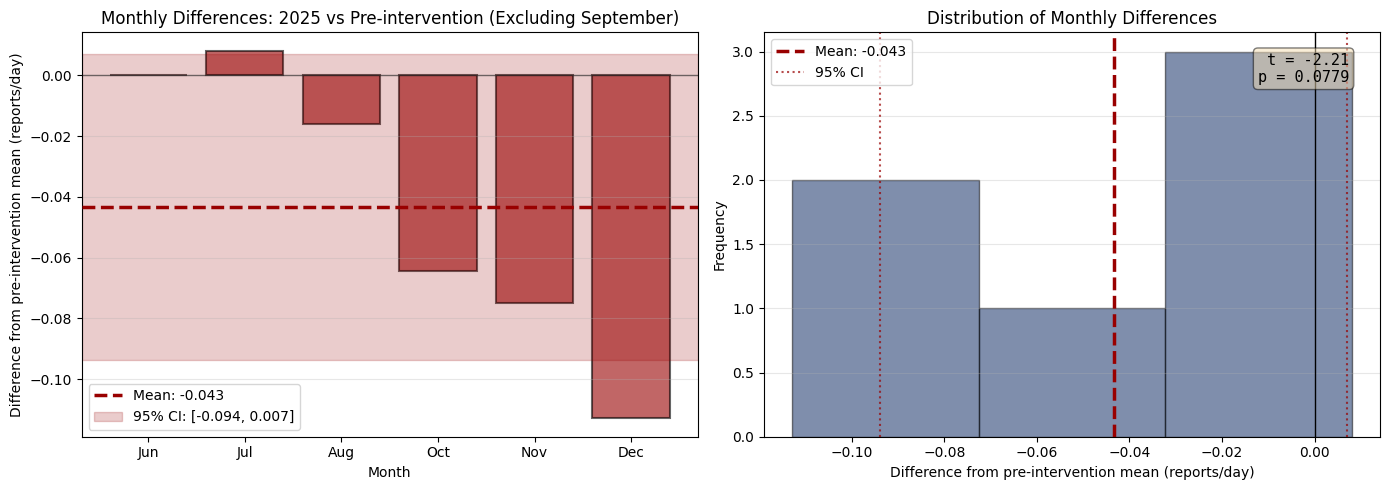

In [78]:
## Compute effect size and significance from detrended residuals
## CORRECTED: Missing months = 0 reports
# ----------------------------
# Observed: avg/day by month x year (with zeros for missing months)
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

# Count reports by year and month
monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

# CRITICAL: Force all 12 months for all years, missing months = 0
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)  # <-- missing months become 0
    .reset_index()
)

# Compute avg per day
monthly_counts["days_in_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
).dt.days_in_month
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - 6  # June=0

# Check for December 2025
print("Checking December 2025:")
dec_2025 = monthly_counts[(monthly_counts["year"] == 2025) & (monthly_counts["month"] == 12)]
print(dec_2025[["year", "month", "n", "avg_per_day"]])
print()

obs = monthly_counts.copy()

# Split into pre and post intervention periods
obs_pre_intervention = obs[
    (obs["year"] < 2025) | 
    ((obs["year"] == 2025) & (obs["month"] < 6))
].copy()
obs_post_intervention_historical = obs[
    (obs["year"] < 2025) & (obs["month"] >= 6)
].copy()
obs_post_intervention_2025 = obs[
    (obs["year"] == 2025) & (obs["month"] >= 6)
].copy()

# Compute averages
pre_summary = obs_pre_intervention.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

post_historical_summary = obs_post_intervention_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean",
    std="std"
).reset_index()

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
f_a_post = np.asarray(model.samples["f_a"])
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S

ref_year = 2021
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])
month_breaks = month_breaks / month_breaks[-1] * S

grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

# ----------------------------
# Rescale model to match pre-intervention data only
# ----------------------------
from scipy.optimize import curve_fit

def linear_transform(x, scale, offset):
    return scale * x + offset

# Fit model to pre-intervention average
popt, _ = curve_fit(
    linear_transform,
    fa_mean_month,
    pre_summary["mean"]
)
scale_fit, offset_fit = popt

fa_mean_month_scaled = scale_fit * fa_mean_month + offset_fit
fa_lo_month_scaled = scale_fit * fa_lo_month + offset_fit
fa_hi_month_scaled = scale_fit * fa_hi_month + offset_fit

print(f"Model rescaling: scale={scale_fit:.3f}, offset={offset_fit:.3f}\n")

# ----------------------------
# De-trend: subtract fitted model mean from observations
# ----------------------------
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

pre_summary["residual"] = pre_summary["mean"] - pre_summary["month_centered"].map(model_baseline)
post_historical_summary["residual"] = post_historical_summary["mean"] - post_historical_summary["month_centered"].map(model_baseline)
obs_post_intervention_2025["residual"] = obs_post_intervention_2025["avg_per_day"] - obs_post_intervention_2025["month_centered"].map(model_baseline)

model_ci_lower = fa_lo_month_scaled - fa_mean_month_scaled
model_ci_upper = fa_hi_month_scaled - fa_mean_month_scaled

# ----------------------------
# Compute month-by-month differences (EXCLUDING SEPTEMBER)
# ----------------------------
from scipy import stats

monthly_differences = []
month_names_included = []

print("Post-intervention months (2025):")
print("-" * 60)
for month in range(6, 13):
    # Get historical values for this month (from pre-intervention period)
    historical_values = obs_pre_intervention[obs_pre_intervention["month"] == month]["avg_per_day"].values
    
    # Get 2025 value for this month
    current_values = obs_post_intervention_2025[obs_post_intervention_2025["month"] == month]["avg_per_day"].values
    
    hist_mean = np.mean(historical_values) if len(historical_values) > 0 else 0
    current_value = current_values[0] if len(current_values) > 0 else 0
    
    print(f"  {calendar.month_abbr[month]:>3}: n_historical={len(historical_values)}, "
          f"hist_mean={hist_mean:.3f}, 2025_value={current_value:.3f}")
    
    # Skip September in the statistical test
    if month == 9:
        print(f"       → EXCLUDED from analysis (outlier)")
        continue
    
    # The difference for this month
    diff = current_value - hist_mean
    monthly_differences.append(diff)
    month_names_included.append(calendar.month_abbr[month])

print("-" * 60)

# Convert to array
monthly_differences = np.array(monthly_differences)

# ----------------------------
# Aggregate statistics across months
# ----------------------------

# Mean difference across months
mean_diff = np.mean(monthly_differences)
std_diff = np.std(monthly_differences, ddof=1)
se_diff = std_diff / np.sqrt(len(monthly_differences))

# One-sample t-test: are the monthly differences significantly different from zero?
t_stat, p_value = stats.ttest_1samp(monthly_differences, 0)

# 95% CI for mean difference
ci_lower = mean_diff - stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff
ci_upper = mean_diff + stats.t.ppf(0.975, len(monthly_differences) - 1) * se_diff

# Effect size: mean difference divided by std of differences
cohens_d = mean_diff / std_diff if std_diff > 0 else np.nan

# ----------------------------
# Print results
# ----------------------------
print("\n" + "=" * 80)
print("INTERVENTION EFFECT ANALYSIS (CORRECTED: Missing months = 0)")
print("Month-by-month differences aggregated into single statistic")
print("=" * 80)
print(f"\nMethod: For each post-intervention month (Jun-Dec 2025, EXCEPT SEP), compute")
print(f"        difference from pre-intervention average for that same month (2021-2025 Jan-May).")
print(f"        Missing months are treated as 0 reports.")
print(f"        Then test if mean difference across months is significantly non-zero.")
print("\n" + "-" * 80)

print(f"\nMonthly differences (2025 - Pre-intervention mean):")
for month_name, diff in zip(month_names_included, monthly_differences):
    print(f"  {month_name}: {diff:>8.3f} reports/day")
print(f"  Sep: EXCLUDED (outlier)")

print("\n" + "-" * 80)
print(f"AGGREGATE EFFECT ACROSS MONTHS (excluding September):")
print("-" * 80)
print(f"  Number of months:        {len(monthly_differences)}")
print(f"  Mean difference:         {mean_diff:>7.3f} reports/day")
print(f"  Std of differences:      {std_diff:>7.3f}")
print(f"  95% CI:                  [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  Cohen's d:               {cohens_d:>7.3f}")
print(f"\n  t-statistic:             {t_stat:>7.3f}")
print(f"  p-value:                 {p_value:>7.4f}")
print(f"  Significance:            {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\nInterpretation:")
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"
    
print(f"  Effect size:             {effect_interp}")

if p_value < 0.05:
    direction = "decreased" if mean_diff < 0 else "increased"
    print(f"\n  ✓ The intervention significantly {direction} illegal dumping reports")
    print(f"    by an average of {abs(mean_diff):.3f} reports/day per month,")
    print(f"    after accounting for seasonal patterns.")
    
    # Percentage change (relative to typical scale)
    typical_scale = np.mean([np.mean(obs_pre_intervention[obs_pre_intervention["month"] == m]["avg_per_day"]) 
                            for m in range(6, 13) if m != 9 and len(obs_pre_intervention[obs_pre_intervention["month"] == m]) > 0])
    pct_change = (mean_diff / typical_scale) * 100 if typical_scale > 0 else np.nan
    if not np.isnan(pct_change):
        print(f"    This represents approximately a {pct_change:.1f}% change.")
else:
    print(f"\n  ✗ No significant change detected after intervention.")
    print(f"    Mean difference of {mean_diff:.3f} reports/day could be due to chance")
    print(f"    (p = {p_value:.4f}).")

print("=" * 80)

# ----------------------------
# Visualization
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Individual monthly differences
x_pos = np.arange(len(monthly_differences))
colors = ['#990000' if mean_diff < 0 else '#011f5b' for _ in monthly_differences]

bars = ax1.bar(x_pos, monthly_differences, color=colors, alpha=0.6, edgecolor='black', linewidth=1.5)

# Mean line
ax1.axhline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}', zorder=5)

# Confidence interval band
ax1.axhspan(ci_lower, ci_upper, alpha=0.2, color='#990000', 
           label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')

# Zero line
ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names_included)
ax1.set_ylabel('Difference from pre-intervention mean (reports/day)')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Differences: 2025 vs Pre-intervention (Excluding September)')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Distribution and inference
ax2.hist(monthly_differences, bins=max(3, len(monthly_differences)//2), 
         color='#011f5b', alpha=0.5, edgecolor='black')

# Add mean and CI
ax2.axvline(mean_diff, color='#990000', linestyle='--', linewidth=2.5, 
           label=f'Mean: {mean_diff:.3f}')
ax2.axvline(ci_lower, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(ci_upper, color='#990000', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'95% CI')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)

# Add test result text
sig_text = f"t = {t_stat:.2f}\np = {p_value:.4f}"
if p_value < 0.001:
    sig_text += "\n***"
elif p_value < 0.01:
    sig_text += "\n**"
elif p_value < 0.05:
    sig_text += "\n*"

ax2.text(0.95, 0.95, sig_text, transform=ax2.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11, fontfamily='monospace')

ax2.set_xlabel('Difference from pre-intervention mean (reports/day)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Monthly Differences')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

SEASONALLY ADJUSTED VALUES ANALYSIS

Values above zero = higher-than-typical activity for the region
Values below zero = lower-than-typical activity for the region
This helps place intervention effect in broader regional context.



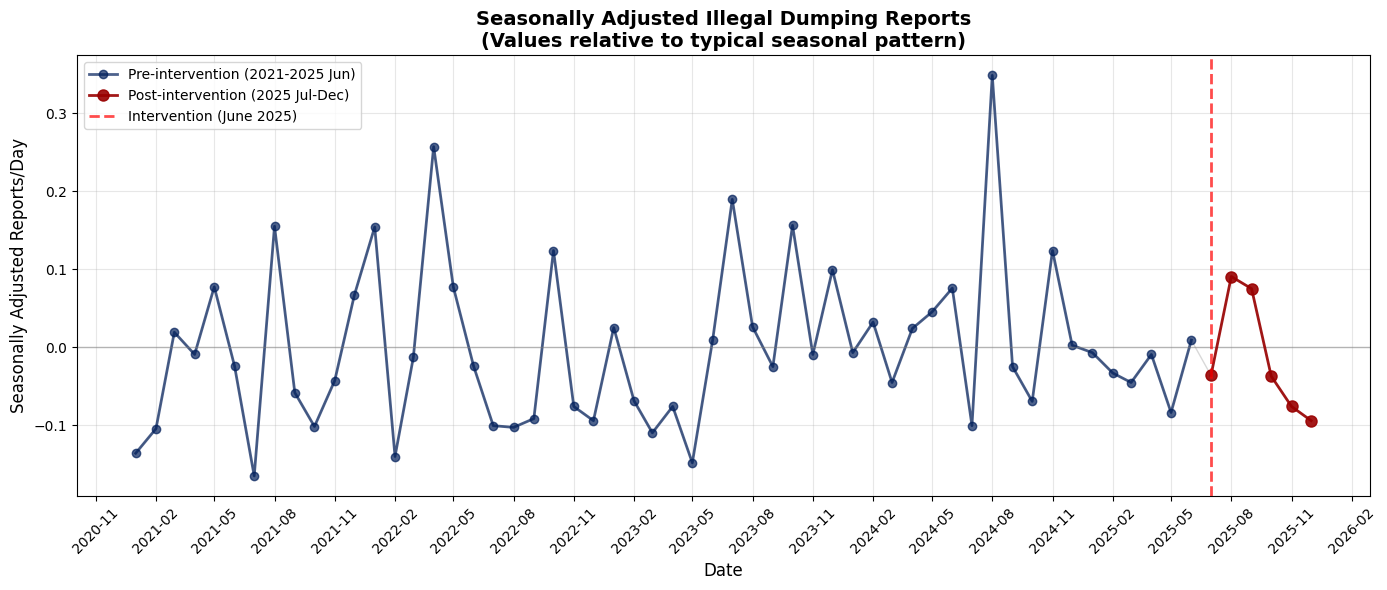


PRE vs POST INTERVENTION COMPARISON (Seasonally Adjusted Values)

Pre-intervention period: 2021-2025 Jun
  N:           54
  Mean:         -0.001 reports/day
  Std:           0.104

Post-intervention period: 2025 Jul-Dec
  N:           6 (all months)
  Mean:         -0.013 reports/day
  Std:           0.078

Post-intervention period: 2025 Jul-Dec (excluding September)
  N:           5
  Mean:         -0.031 reports/day
  Std:           0.072

--------------------------------------------------------------------------------
STATISTICAL TEST RESULTS:
--------------------------------------------------------------------------------

With September included:
  Mean difference:   -0.012 reports/day
  t-statistic:       0.348
  p-value:          0.7380
  Cohen's d:        -0.118
  Significance:    ns

Without September:
  Mean difference:   -0.030 reports/day
  t-statistic:       0.841
  p-value:          0.4343
  Cohen's d:        -0.290
  Significance:    ns

Note: This test ignores autocor

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_77346/2938217932.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=['Pre\n(2021-2025 Jun)', 'Post\n(2025 Jul-Dec\nno Sep)'],
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_77346/2938217932.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


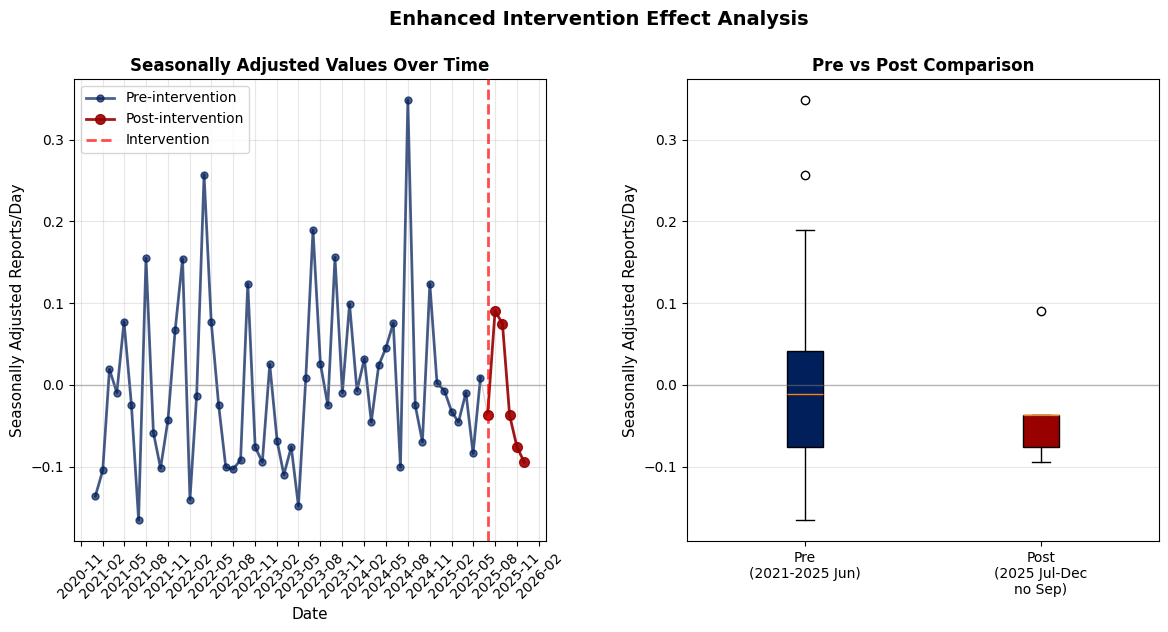


TEST: 2025 JUL-DEC vs SEASONAL MODEL PREDICTIONS

Question: Are the July-December 2025 observations significantly different
         from what the seasonal model predicts for those months?

Method: One-sample t-test on seasonally adjusted values (residuals)
        Testing if residuals are significantly different from zero
        (Zero = no difference from seasonal prediction)

--------------------------------------------------------------------------------
RESULTS (excluding September):
--------------------------------------------------------------------------------
  Months analyzed:     Jul, Aug, Oct, Nov, Dec 2025 (N = 5)
  Mean residual:        -0.031 reports/day
  Std of residuals:      0.072
  95% CI:              [-0.121, 0.059]

  t-statistic:          -0.951
  p-value:              0.3955
  Significance:        ns
  Effect size:          -0.425

--------------------------------------------------------------------------------
RESULTS (including September):
------------------

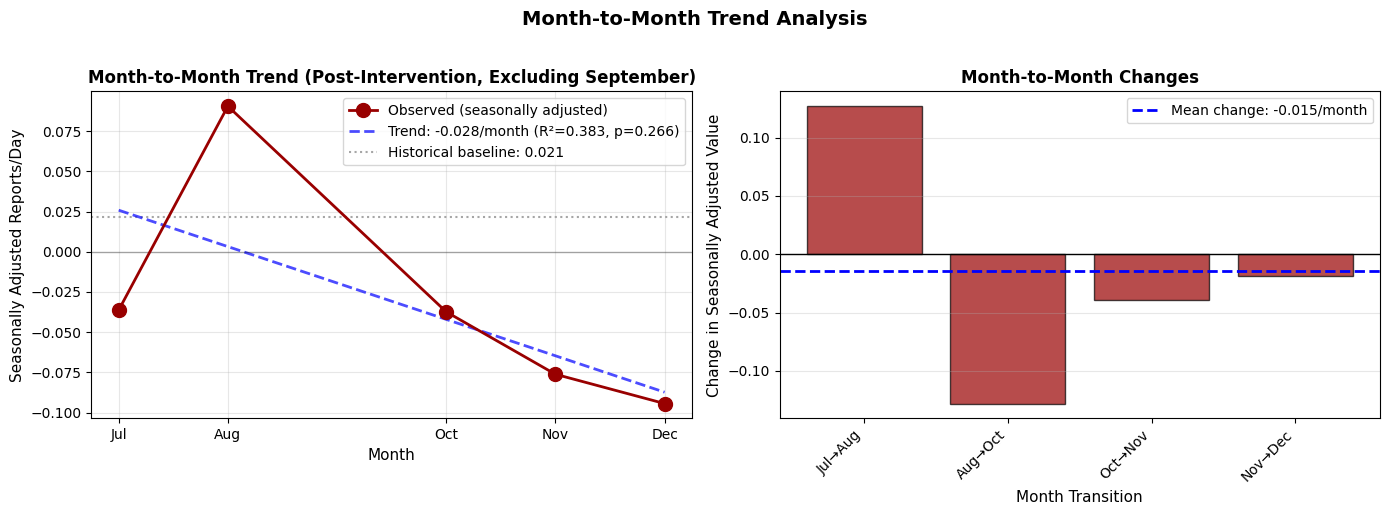


SUMMARY OF FINDINGS

1. Pre-intervention average (seasonally adjusted): -0.001 reports/day
2. Post-intervention average (seasonally adjusted, no Sep): -0.031 reports/day
3. Mean difference (pre vs post): -0.030 reports/day
4. Pre vs Post t-test: Not significant (p = 0.4343)
5. Effect size (Cohen's d, pre vs post): -0.290

6. 2025 Jul-Dec vs Model Prediction: Not significant (p = 0.3955)
   Mean residual from model: -0.031 reports/day
   Interpretation: Post-intervention values are consistent with seasonal predictions

7. Month-to-Month Trend (Post-Intervention): Not significant (p = 0.2656)
   Slope (change per month): -0.028 reports/day per month
   R-squared: 0.383
   Interpretation: No significant trend detected - month-to-month changes
   could be due to random variation rather than systematic decline.


In [84]:
## Enhanced Intervention Effect Analysis
## Seasonally adjusted values and improved statistical tests
# ----------------------------
# 1. Create seasonally adjusted values (residuals)
# ----------------------------

# Ensure we have the model baseline
model_baseline = dict(zip(months_centered, fa_mean_month_scaled))

# Add seasonally adjusted values (residuals) to all observations
obs["seasonally_adjusted"] = obs["avg_per_day"] - obs["month_centered"].map(model_baseline)

# Split into pre and post intervention
# Note: Intervention is in June, so post-intervention starts in July (month >= 7)
obs_pre = obs[(obs["year"] < 2025) | ((obs["year"] == 2025) & (obs["month"] < 7))].copy()
obs_post = obs[(obs["year"] == 2025) & (obs["month"] >= 7)].copy()

# ----------------------------
# 2. Seasonally Adjusted Values Plot (Companion Plot)
# ----------------------------
print("=" * 80)
print("SEASONALLY ADJUSTED VALUES ANALYSIS")
print("=" * 80)
print("\nValues above zero = higher-than-typical activity for the region")
print("Values below zero = lower-than-typical activity for the region")
print("This helps place intervention effect in broader regional context.\n")

# Create time series for plotting
obs_plot = obs.copy()
obs_plot["date"] = pd.to_datetime(obs_plot["year"].astype(str) + "-" + obs_plot["month"].astype(str) + "-01")
obs_plot = obs_plot.sort_values("date")

# Separate pre and post for visualization
obs_plot_pre = obs_plot[obs_plot["date"] < pd.Timestamp("2025-07-01")]
obs_plot_post = obs_plot[obs_plot["date"] >= pd.Timestamp("2025-07-01")]

fig, ax = plt.subplots(figsize=(14, 6))

# Plot all data as continuous line first
ax.plot(obs_plot["date"], obs_plot["seasonally_adjusted"], 
        '-', color='gray', alpha=0.3, linewidth=1, zorder=1)

# Plot pre-intervention with markers
ax.plot(obs_plot_pre["date"], obs_plot_pre["seasonally_adjusted"], 
        'o-', color='#011f5b', alpha=0.7, markersize=6, linewidth=2, label='Pre-intervention (2021-2025 Jun)', zorder=2)

# Plot post-intervention with markers
ax.plot(obs_plot_post["date"], obs_plot_post["seasonally_adjusted"], 
        'o-', color='#990000', alpha=0.9, markersize=8, linewidth=2, label='Post-intervention (2025 Jul-Dec)', zorder=3)

# Intervention line
ax.axvline(pd.Timestamp("2025-07-01"), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Intervention (June 2025)', zorder=4)

# Zero line
ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Seasonally Adjusted Reports/Day', fontsize=12)
ax.set_title('Seasonally Adjusted Illegal Dumping Reports\n(Values relative to typical seasonal pattern)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ----------------------------
# 3. Pre vs Post Comparison with t-test (on seasonally adjusted values)
# ----------------------------
from scipy import stats

# Get seasonally adjusted values
pre_adjusted = obs_pre["seasonally_adjusted"].values
post_adjusted = obs_post["seasonally_adjusted"].values

# Exclude September from post if desired
post_adjusted_no_sep = obs_post[obs_post["month"] != 9]["seasonally_adjusted"].values

print("\n" + "=" * 80)
print("PRE vs POST INTERVENTION COMPARISON (Seasonally Adjusted Values)")
print("=" * 80)

# Statistics
pre_mean = np.mean(pre_adjusted)
pre_std = np.std(pre_adjusted, ddof=1)
pre_n = len(pre_adjusted)

post_mean = np.mean(post_adjusted)
post_std = np.std(post_adjusted, ddof=1)
post_n = len(post_adjusted)

post_mean_no_sep = np.mean(post_adjusted_no_sep)
post_std_no_sep = np.std(post_adjusted_no_sep, ddof=1)
post_n_no_sep = len(post_adjusted_no_sep)

# Two-sample t-test (with September)
t_stat, p_value = stats.ttest_ind(pre_adjusted, post_adjusted, equal_var=False)

# Two-sample t-test (without September)
t_stat_no_sep, p_value_no_sep = stats.ttest_ind(pre_adjusted, post_adjusted_no_sep, equal_var=False)

# Effect size (Cohen's d)
pooled_std = np.sqrt(((pre_n - 1) * pre_std**2 + (post_n - 1) * post_std**2) / (pre_n + post_n - 2))
cohens_d = (post_mean - pre_mean) / pooled_std if pooled_std > 0 else np.nan

pooled_std_no_sep = np.sqrt(((pre_n - 1) * pre_std**2 + (post_n_no_sep - 1) * post_std_no_sep**2) / (pre_n + post_n_no_sep - 2))
cohens_d_no_sep = (post_mean_no_sep - pre_mean) / pooled_std_no_sep if pooled_std_no_sep > 0 else np.nan

print(f"\nPre-intervention period: 2021-2025 Jun")
print(f"  N:           {pre_n}")
print(f"  Mean:        {pre_mean:>7.3f} reports/day")
print(f"  Std:         {pre_std:>7.3f}")

print(f"\nPost-intervention period: 2025 Jul-Dec")
print(f"  N:           {post_n} (all months)")
print(f"  Mean:        {post_mean:>7.3f} reports/day")
print(f"  Std:         {post_std:>7.3f}")

print(f"\nPost-intervention period: 2025 Jul-Dec (excluding September)")
print(f"  N:           {post_n_no_sep}")
print(f"  Mean:        {post_mean_no_sep:>7.3f} reports/day")
print(f"  Std:         {post_std_no_sep:>7.3f}")

print("\n" + "-" * 80)
print("STATISTICAL TEST RESULTS:")
print("-" * 80)

print(f"\nWith September included:")
print(f"  Mean difference:  {post_mean - pre_mean:>7.3f} reports/day")
print(f"  t-statistic:     {t_stat:>7.3f}")
print(f"  p-value:         {p_value:>7.4f}")
print(f"  Cohen's d:       {cohens_d:>7.3f}")
print(f"  Significance:    {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print(f"\nWithout September:")
print(f"  Mean difference:  {post_mean_no_sep - pre_mean:>7.3f} reports/day")
print(f"  t-statistic:     {t_stat_no_sep:>7.3f}")
print(f"  p-value:         {p_value_no_sep:>7.4f}")
print(f"  Cohen's d:       {cohens_d_no_sep:>7.3f}")
print(f"  Significance:    {'***' if p_value_no_sep < 0.001 else '**' if p_value_no_sep < 0.01 else '*' if p_value_no_sep < 0.05 else 'ns'}")

print("\nNote: This test ignores autocorrelation but provides a simple comparison")
print("      for this interim report.")
print("=" * 80)

# ----------------------------
# 4. Comprehensive Visualization
# ----------------------------
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.3)

# Panel 1: Seasonally adjusted time series
ax1 = fig.add_subplot(gs[0, 0])
# Plot all data as continuous line first
ax1.plot(obs_plot["date"], obs_plot["seasonally_adjusted"], 
         '-', color='gray', alpha=0.3, linewidth=1, zorder=1)
# Plot pre-intervention with markers
ax1.plot(obs_plot_pre["date"], obs_plot_pre["seasonally_adjusted"], 
         'o-', color='#011f5b', alpha=0.7, markersize=5, linewidth=2, label='Pre-intervention', zorder=2)
# Plot post-intervention with markers
ax1.plot(obs_plot_post["date"], obs_plot_post["seasonally_adjusted"], 
         'o-', color='#990000', alpha=0.9, markersize=7, linewidth=2, label='Post-intervention', zorder=3)
ax1.axvline(pd.Timestamp("2025-07-01"), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Intervention', zorder=4)
ax1.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Seasonally Adjusted Reports/Day', fontsize=11)
ax1.set_title('Seasonally Adjusted Values Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Panel 2: Pre vs Post comparison
ax2 = fig.add_subplot(gs[0, 1])
data_to_plot = [pre_adjusted, post_adjusted_no_sep]
bp = ax2.boxplot(data_to_plot, labels=['Pre\n(2021-2025 Jun)', 'Post\n(2025 Jul-Dec\nno Sep)'], 
                 patch_artist=True)
bp['boxes'][0].set_facecolor('#011f5b')
bp['boxes'][1].set_facecolor('#990000')
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_ylabel('Seasonally Adjusted Reports/Day', fontsize=11)
ax2.set_title('Pre vs Post Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add significance annotation
if p_value_no_sep < 0.05:
    y_max = max([max(d) for d in data_to_plot])
    ax2.plot([1, 2], [y_max * 1.1, y_max * 1.1], 'k-', linewidth=1)
    ax2.text(1.5, y_max * 1.15, '*' if p_value_no_sep < 0.05 else '', 
             ha='center', fontsize=14, fontweight='bold')

plt.suptitle('Enhanced Intervention Effect Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ----------------------------
# 4b. Test: Are 2025 Jul-Dec values different from seasonal model predictions?
# ----------------------------
print("\n" + "=" * 80)
print("TEST: 2025 JUL-DEC vs SEASONAL MODEL PREDICTIONS")
print("=" * 80)
print("\nQuestion: Are the July-December 2025 observations significantly different")
print("         from what the seasonal model predicts for those months?")
print("\nMethod: One-sample t-test on seasonally adjusted values (residuals)")
print("        Testing if residuals are significantly different from zero")
print("        (Zero = no difference from seasonal prediction)\n")

# Get post-intervention residuals (excluding September)
post_residuals = obs_post[obs_post["month"] != 9]["seasonally_adjusted"].values
post_residuals_all = obs_post["seasonally_adjusted"].values

# One-sample t-test: test if mean residual is different from zero
t_stat_residual, p_value_residual = stats.ttest_1samp(post_residuals, 0)
t_stat_residual_all, p_value_residual_all = stats.ttest_1samp(post_residuals_all, 0)

# Calculate mean and confidence interval
mean_residual = np.mean(post_residuals)
std_residual = np.std(post_residuals, ddof=1)
n_residual = len(post_residuals)
se_residual = std_residual / np.sqrt(n_residual)
ci_lower_residual = mean_residual - stats.t.ppf(0.975, n_residual - 1) * se_residual
ci_upper_residual = mean_residual + stats.t.ppf(0.975, n_residual - 1) * se_residual

# Effect size (mean residual / std of residuals)
cohens_d_residual = mean_residual / std_residual if std_residual > 0 else np.nan

print("-" * 80)
print("RESULTS (excluding September):")
print("-" * 80)
print(f"  Months analyzed:     Jul, Aug, Oct, Nov, Dec 2025 (N = {n_residual})")
print(f"  Mean residual:       {mean_residual:>7.3f} reports/day")
print(f"  Std of residuals:    {std_residual:>7.3f}")
print(f"  95% CI:              [{ci_lower_residual:.3f}, {ci_upper_residual:.3f}]")
print(f"\n  t-statistic:         {t_stat_residual:>7.3f}")
print(f"  p-value:             {p_value_residual:>7.4f}")
print(f"  Significance:        {'***' if p_value_residual < 0.001 else '**' if p_value_residual < 0.01 else '*' if p_value_residual < 0.05 else 'ns'}")
print(f"  Effect size:         {cohens_d_residual:>7.3f}")

print("\n" + "-" * 80)
print("RESULTS (including September):")
print("-" * 80)
print(f"  Months analyzed:     Jul, Aug, Sep, Oct, Nov, Dec 2025 (N = {len(post_residuals_all)})")
print(f"  Mean residual:       {np.mean(post_residuals_all):>7.3f} reports/day")
print(f"  t-statistic:         {t_stat_residual_all:>7.3f}")
print(f"  p-value:             {p_value_residual_all:>7.4f}")
print(f"  Significance:        {'***' if p_value_residual_all < 0.001 else '**' if p_value_residual_all < 0.01 else '*' if p_value_residual_all < 0.05 else 'ns'}")

print("\n" + "-" * 80)
print("INTERPRETATION:")
print("-" * 80)
if p_value_residual < 0.05:
    direction = "lower" if mean_residual < 0 else "higher"
    print(f"  ✓ The 2025 Jul-Dec values are significantly {direction} than the seasonal model predicts")
    print(f"    Mean difference: {abs(mean_residual):.3f} reports/day")
    if mean_residual < 0:
        print(f"    This suggests the intervention may have reduced reports below expected seasonal levels.")
    else:
        print(f"    This suggests reports were higher than expected for this time of year.")
else:
    print(f"  ✗ No significant difference detected")
    print(f"    The 2025 Jul-Dec values are consistent with what the seasonal model predicts")
    print(f"    (p = {p_value_residual:.4f}). The observed difference could be due to chance.")

print("\nNote: This test compares actual values to model predictions, not pre vs post periods.")
print("      A significant result means the post-intervention months differ from expected")
print("      seasonal patterns, which could indicate an intervention effect.")
print("=" * 80)

# ----------------------------
# 4c. Test: Month-to-Month Trend Analysis (Declining trend in post-intervention period)
# ----------------------------
print("\n" + "=" * 80)
print("MONTH-TO-MONTH TREND ANALYSIS")
print("=" * 80)
print("\nQuestion: Is there a significant declining trend month-to-month in the")
print("         post-intervention period (relative to historical baseline)?")
print("\nMethod: Linear regression on seasonally adjusted values over time")
print("        Testing if the slope (month-to-month change) is significantly different from zero")
print("        (Excluding September as outlier)\n")

# Get post-intervention months (excluding September) sorted by month
obs_post_trend = obs_post[obs_post["month"] != 9].copy().sort_values("month")
months_trend = obs_post_trend["month"].values
adjusted_trend = obs_post_trend["seasonally_adjusted"].values

# Also get the month number as a sequence (1, 2, 3, ...) for regression
month_sequence = np.arange(1, len(months_trend) + 1)

# Linear regression: seasonally adjusted value ~ month sequence
from scipy.stats import linregress

slope, intercept, r_value, p_value_trend, std_err = linregress(month_sequence, adjusted_trend)

# Calculate month-to-month changes
monthly_changes = np.diff(adjusted_trend)

# Calculate mean historical baseline for comparison
# Get historical values for the same months (Jul, Aug, Oct, Nov, Dec)
historical_baseline = []
for month in months_trend:
    hist_values = obs_pre[obs_pre["month"] == month]["seasonally_adjusted"].values
    if len(hist_values) > 0:
        historical_baseline.append(np.mean(hist_values))
historical_baseline_mean = np.mean(historical_baseline) if len(historical_baseline) > 0 else 0

print("-" * 80)
print("MONTH-BY-MONTH CHANGES (Relative to Historical Baseline):")
print("-" * 80)
print(f"\nHistorical baseline (mean for these months): {historical_baseline_mean:.3f} reports/day\n")

for i, (month, value, change) in enumerate(zip(months_trend, adjusted_trend, 
                                                np.concatenate([[np.nan], monthly_changes]))):
    month_name = calendar.month_abbr[month]
    diff_from_baseline = value - historical_baseline_mean
    
    if i == 0:
        print(f"  {month_name:>3} 2025: {value:>7.3f} (diff from baseline: {diff_from_baseline:>7.3f})")
    else:
        prev_month_name = calendar.month_abbr[months_trend[i-1]]
        print(f"  {month_name:>3} 2025: {value:>7.3f} (diff from baseline: {diff_from_baseline:>7.3f}, "
              f"change from {prev_month_name}: {change:>7.3f})")

print("\n" + "-" * 80)
print("TREND ANALYSIS (Linear Regression):")
print("-" * 80)
print(f"  Slope (change per month):  {slope:>7.3f} reports/day per month")
print(f"  Intercept:                  {intercept:>7.3f}")
print(f"  R-squared:                  {r_value**2:>7.3f}")
print(f"  Standard error of slope:   {std_err:>7.3f}")
print(f"  t-statistic:                {slope/std_err:>7.3f}")
print(f"  p-value (trend):            {p_value_trend:>7.4f}")
print(f"  Significance:              {'***' if p_value_trend < 0.001 else '**' if p_value_trend < 0.01 else '*' if p_value_trend < 0.05 else 'ns'}")

# 95% CI for slope
df = len(month_sequence) - 2
t_critical = stats.t.ppf(0.975, df)
slope_ci_lower = slope - t_critical * std_err
slope_ci_upper = slope + t_critical * std_err

print(f"  95% CI for slope:           [{slope_ci_lower:.3f}, {slope_ci_upper:.3f}]")

print("\n" + "-" * 80)
print("INTERPRETATION:")
print("-" * 80)
if p_value_trend < 0.05:
    direction = "decreasing" if slope < 0 else "increasing"
    print(f"  ✓ Significant {direction} trend detected")
    print(f"    On average, seasonally adjusted values change by {slope:.3f} reports/day per month")
    if slope < 0:
        print(f"    This represents a {abs(slope):.3f} reports/day decline per month")
        print(f"    Over the {len(months_trend)}-month period, this suggests a cumulative decline")
        print(f"    of approximately {abs(slope) * (len(months_trend) - 1):.3f} reports/day")
    else:
        print(f"    This represents a {slope:.3f} reports/day increase per month")
else:
    print(f"  ✗ No significant trend detected (p = {p_value_trend:.4f})")
    print(f"    The month-to-month changes could be due to random variation")
    print(f"    rather than a systematic trend.")

print("\nNote: A negative slope indicates declining reports relative to historical baseline.")
print("      This would be consistent with an intervention effect strengthening over time.")
print("=" * 80)

# ----------------------------
# Visualization of trend
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Time series with trend line
ax1.plot(months_trend, adjusted_trend, 'o-', color='#990000', markersize=10, 
         linewidth=2, label='Observed (seasonally adjusted)', zorder=3)
# Add regression line
x_line = np.linspace(months_trend.min(), months_trend.max(), 100)
# Map back to month sequence for regression line
x_seq = np.linspace(1, len(months_trend), 100)
y_line = slope * x_seq + intercept
# Convert back to month numbers for plotting
x_line_months = np.linspace(months_trend.min(), months_trend.max(), 100)
ax1.plot(x_line_months, y_line, '--', color='blue', alpha=0.7, linewidth=2, 
         label=f'Trend: {slope:.3f}/month (R²={r_value**2:.3f}, p={p_value_trend:.3f})', zorder=2)
ax1.axhline(historical_baseline_mean, color='gray', linestyle=':', linewidth=1.5, 
           alpha=0.7, label=f'Historical baseline: {historical_baseline_mean:.3f}', zorder=1)
ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Seasonally Adjusted Reports/Day', fontsize=11)
ax1.set_title('Month-to-Month Trend (Post-Intervention, Excluding September)', fontsize=12, fontweight='bold')
ax1.set_xticks(months_trend)
ax1.set_xticklabels([calendar.month_abbr[m] for m in months_trend])
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: Month-to-month changes
ax2.bar(range(len(monthly_changes)), monthly_changes, color='#990000', alpha=0.7, edgecolor='black')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Month Transition', fontsize=11)
ax2.set_ylabel('Change in Seasonally Adjusted Value', fontsize=11)
ax2.set_title('Month-to-Month Changes', fontsize=12, fontweight='bold')
# Label x-axis with month transitions
month_labels = [f"{calendar.month_abbr[months_trend[i]]}→{calendar.month_abbr[months_trend[i+1]]}" 
                for i in range(len(monthly_changes))]
ax2.set_xticks(range(len(monthly_changes)))
ax2.set_xticklabels(month_labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
# Add mean change line
mean_change = np.mean(monthly_changes)
ax2.axhline(mean_change, color='blue', linestyle='--', linewidth=2, 
           label=f'Mean change: {mean_change:.3f}/month')
ax2.legend()

plt.suptitle('Month-to-Month Trend Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------
# 5. Summary Table
# ----------------------------
print("\n" + "=" * 80)
print("SUMMARY OF FINDINGS")
print("=" * 80)
print(f"\n1. Pre-intervention average (seasonally adjusted): {pre_mean:.3f} reports/day")
print(f"2. Post-intervention average (seasonally adjusted, no Sep): {post_mean_no_sep:.3f} reports/day")
print(f"3. Mean difference (pre vs post): {post_mean_no_sep - pre_mean:.3f} reports/day")
print(f"4. Pre vs Post t-test: {'Significant' if p_value_no_sep < 0.05 else 'Not significant'} (p = {p_value_no_sep:.4f})")
print(f"5. Effect size (Cohen's d, pre vs post): {cohens_d_no_sep:.3f}")
print(f"\n6. 2025 Jul-Dec vs Model Prediction: {'Significant' if p_value_residual < 0.05 else 'Not significant'} (p = {p_value_residual:.4f})")
print(f"   Mean residual from model: {mean_residual:.3f} reports/day")
print(f"   Interpretation: Post-intervention values are {'significantly different from' if p_value_residual < 0.05 else 'consistent with'} seasonal predictions")
print(f"\n7. Month-to-Month Trend (Post-Intervention): {'Significant' if p_value_trend < 0.05 else 'Not significant'} (p = {p_value_trend:.4f})")
print(f"   Slope (change per month): {slope:.3f} reports/day per month")
print(f"   R-squared: {r_value**2:.3f}")
if p_value_trend < 0.05:
    trend_direction = "declining" if slope < 0 else "increasing"
    print(f"   Interpretation: Significant {trend_direction} trend detected")
    if slope < 0:
        print(f"   This suggests reports are declining by {abs(slope):.3f} reports/day per month")
        print(f"   relative to historical baseline, consistent with strengthening intervention effect.")
else:
    print(f"   Interpretation: No significant trend detected - month-to-month changes")
    print(f"   could be due to random variation rather than systematic decline.")
print("=" * 80)
